## DS675 Mini Project Spring 2026

#### Dataset: https://www.kaggle.com/datasets/paramjeetsinghds/indian-liver-disease-dataset

#### Team Members:


*   ##### Krishna Vedam
*   ##### Travis Collins
*   ##### Saketh Puramsetti



In [ ]:
# 1. Imports

import time, threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats.mstats import winsorize
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE = 675

In [ ]:
# 2. Load Dataset

train_url = 'https://raw.githubusercontent.com/saketh242/DS675-MiniProject-Saketh-Travis-Krishna/refs/heads/main/data/Training_indian_liver_disease_dataset.csv'
# test_url = 'https://raw.githubusercontent.com/saketh242/DS675-MiniProject-Saketh-Travis-Krishna/refs/heads/main/data/Testing_indian_liver_disease_dataset.csv'

df = pd.read_csv(train_url, on_bad_lines='warn', keep_default_na=False)
print(df.shape)
print(df.head())
print(df.columns.tolist())
print("Target value counts: ")
print(df.iloc[:, -1].value_counts())

print("#rows with >1 NA  : ", (df.isna().sum(axis=1) > 0).sum())
print("#cols with >1 NA  : ", (df.isna().sum(axis=0) > 0).sum())


(68000, 28)
  Patient_ID  Age  Gender         Occupation   BMI Obesity_Class Diet_Quality  \
0     P23743   49    Male  Healthcare Worker  21.0        Normal      Average   
1     P59795   49    Male           Business  22.6        Normal      Healthy   
2     P17597   66    Male  Healthcare Worker  19.5        Normal         Poor   
3     P27987   75  Female      Office Worker  21.5        Normal      Average   
4     P45429   51  Female          Housewife  22.8        Normal         Poor   

  Physical_Activity  Sleep_Hours Smoking_Status  ... Comorb_Diabetes  \
0          Moderate          4.9          Never  ...               0   
1               Low          8.2        Current  ...               0   
2               Low          5.1          Never  ...               0   
3          Moderate          6.2         Former  ...               0   
4               Low          7.8          Never  ...               1   

   Comorb_Hypertension  Comorb_Genetic_History    ALT    AST  Biliru

In [ ]:
# 3. Data Preprocessing
# 3(a)  Features - numerical, binary and categorical lists

numerical_cols = ['Age', 'BMI', 'Sleep_Hours', 'ALT', 'AST', 'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase']
categorical_cols = [col for col in df.columns if col != 'Liver_Disease_Type' and col not in numerical_cols]
binary_cols = [
    col for col in df.columns
    if set(df[col].unique()).issubset({0, 1})
]
non_bin_cat_cols = list(set(categorical_cols) - set(binary_cols) - set(['Patient_ID']))

print("NUMERICAL COLUMNS:", numerical_cols)
print("\nNON BINARY CATEGORICAL COLUMNS:", non_bin_cat_cols)
print("\nBINARY COLUMNS:", binary_cols)

# Print unique values for every categorical column
print("\n--- UNIQUE VALUES IN EVERY CATEGORICAL COLUMN ---")
for col in categorical_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].unique())


NUMERICAL COLUMNS: ['Age', 'BMI', 'Sleep_Hours', 'ALT', 'AST', 'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase']

NON BINARY CATEGORICAL COLUMNS: ['Occupation', 'Alcohol_Consumption', 'Physical_Activity', 'Gender', 'Smoking_Status', 'Diet_Quality', 'Obesity_Class']

BINARY COLUMNS: ['Sym_Fatigue', 'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites', 'Sym_Dark_Urine', 'Sym_Weight_Loss', 'Comorb_Diabetes', 'Comorb_Hypertension', 'Comorb_Genetic_History']

--- UNIQUE VALUES IN EVERY CATEGORICAL COLUMN ---

Patient_ID (68000 unique):
['P23743' 'P59795' 'P17597' ... 'P54887' 'P0861' 'P15796']

Gender (2 unique):
['Male' 'Female']

Occupation (8 unique):
['Healthcare Worker' 'Business' 'Office Worker' 'Housewife' 'Student'
 'Farmer' 'Laborer' 'Retired']

Obesity_Class (6 unique):
['Normal' 'Obesity I' 'Overweight' 'Underweight' 'Obesity II'
 'Obesity III']

Diet_Quality (3 unique):
['Average' 'Healthy' 'Poor']

Physical_Activity (4 unique):
['Moderate' 'Low' 'Sedentary' 

Columns with outliers:
['BMI', 'Sleep_Hours', 'ALT', 'AST', 'Bilirubin']


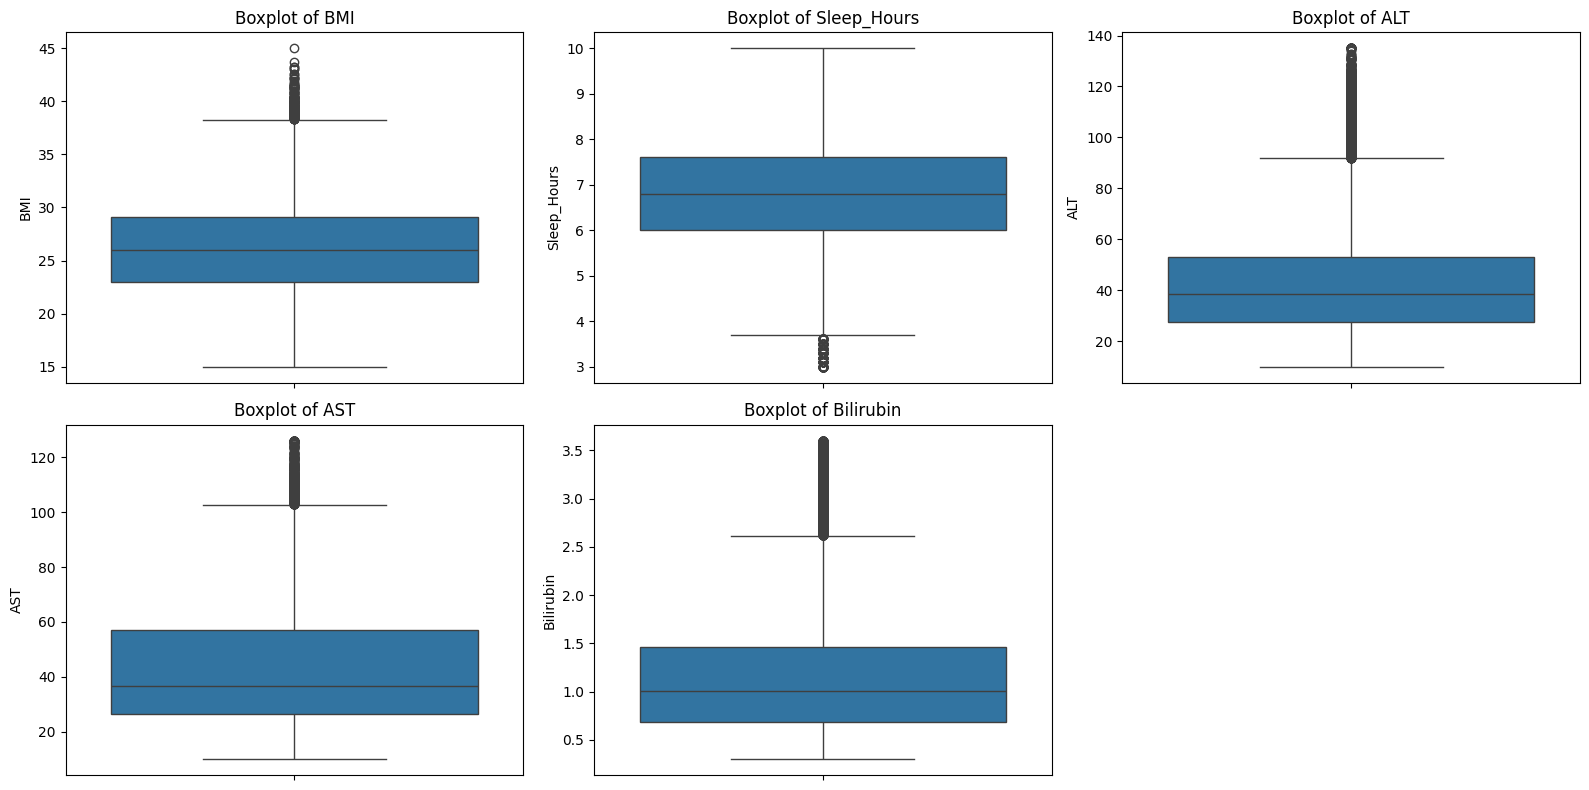

In [ ]:
# 3 (b) Box plots to look for outliers

# Function to detect outliers using IQR method
def has_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).any()

# Select only numerical columns with outliers
cols_with_outliers = [col for col in numerical_cols if has_outliers(df[col])]

print("Columns with outliers:")
print(cols_with_outliers)

# Plot only those columns
n_cols = 3
n_rows = (len(cols_with_outliers) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_with_outliers):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# 3(c) Data preperation - Drop unwanted columns, backfill and encode labels

# Drop Patient_ID
df.drop(columns=['Patient_ID'], inplace=True, errors='ignore')

# Confirm no missing values remain
print("Missing values check:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("All good!" if df.isnull().sum().sum() == 0 else "Still has nulls!")

# Encode target
le_target = LabelEncoder()
df['Liver_Disease_Type'] = le_target.fit_transform(df['Liver_Disease_Type'])
print("\nClass mapping:")
for i, cls in enumerate(le_target.classes_):
    print(f"  {i} → {cls}")

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), non_bin_cat_cols),
    ('bin', 'passthrough', binary_cols)
])

Missing values check:
Series([], dtype: int64)
All good!

Class mapping:
  0 → Alcoholic_Liver_Disease
  1 → Cirrhosis
  2 → Fatty_Liver
  3 → Hepatitis_B
  4 → Hepatitis_C
  5 → Normal


In [ ]:
# 4. Train-Test Split

X = df.drop(columns=['Liver_Disease_Type'])
y = df['Liver_Disease_Type']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("\nClass distribution in train:")
print(pd.Series(y_train).value_counts())

def perform_feature_importance_analysis(fitted_pipeline, Xtest, ytest, modelname="MODEL"):
  result = permutation_importance(fitted_pipeline, Xtest, ytest,
                                  random_state=RANDOM_STATE, n_jobs=-1)

  feature_names = Xtest.columns

  imp_df = pd.DataFrame({'feature': feature_names,
                         'importance': result.importances_mean}
                       ).sort_values(by='importance', ascending=False)

  print(imp_df.head(20))
  imp_df.head(20).plot(x='feature', y='importance',
                              kind='barh', figsize=(8,6))
  plt.gca().invert_yaxis()
  plt.title(f"{modelname} - Permutation Feature Importance")
  plt.xlabel("Importance")
  plt.show()

def perform_confusionmatrix_analysis(ytest, ypredicted, modelname="MODEL"):
  print(confusion_matrix(ytest, ypredicted))
  fig, ax = plt.subplots(figsize=(9, 9))
  ConfusionMatrixDisplay.from_predictions(
      ytest,
      ypredicted,
      display_labels=le_target.classes_,
      cmap='Blues',
      ax=ax
  )
  ax.set_title("Confusion Matrix - " + modelname)
  fig.tight_layout()
  plt.show()
  plt.savefig(modelname + ' - confusion_matrix.png', dpi=150)
  plt.close(fig)

def perform_classification_analysis(ytest, ypredicted, modelname="MODEL"):
  clsfreport = classification_report(ytest, ypredicted, output_dict=True)
  df_report = pd.DataFrame(clsfreport).transpose()

  print(clsfreport)

  fig = plt.figure(figsize=(8, 5))
  sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap='viridis')
  plt.title("Classification Report Heatmap - " + modelname)
  plt.tight_layout()
  plt.show()
  plt.savefig(modelname + ' - classification_report.png', dpi=150)
  plt.close(fig)

def plot_hyperparam_analysis(
    grid_search,
    param_x,
    param_group=None,
    title="Hyperparameter Analysis",
    log_x=False,
    kind="line",
    show_std=False,
    zoom=False,
    rank=False
):
    """
    Generic function to plot hyperparameter behavior from GridSearchCV.

    Args:
        grid_search: fitted GridSearchCV object
        param_x: x-axis parameter (e.g. 'param_mlp__alpha')
        param_group: optional grouping parameter
        title: plot title
        log_x: use log scale on x-axis
        kind: 'line' or 'bar'
        show_std: show std deviation as error bars
        zoom: zoom y-axis for small differences
        rank: show ranked horizontal bar plot
    """

    results_df = pd.DataFrame(grid_search.cv_results_)

    plt.figure(figsize=(7, 5))

    # ---------------------------
    # GROUPED PLOT
    # ---------------------------
    if param_group:
        for group_val in results_df[param_group].unique():
            subset = results_df[results_df[param_group] == group_val]
            grouped = subset.groupby(param_x)['mean_test_score']

            means = grouped.mean()
            stds = grouped.std()

            if kind == "line":
                plt.plot(means.index, means.values, marker='o', label=str(group_val))
            else:
                if show_std:
                    bars = plt.bar(means.index.astype(str), means.values,
                                   yerr=stds.values, capsize=4, alpha=0.7, label=str(group_val))
                else:
                    bars = plt.bar(means.index.astype(str), means.values,
                                   alpha=0.7, label=str(group_val))

                # VALUE LABELS (vertical bars)
                for bar in bars:
                    height = bar.get_height()
                    plt.text(bar.get_x() + bar.get_width()/2,
                             height + 0.0003,
                             f"{height:.4f}",
                             ha='center', va='bottom', fontsize=8)

        plt.legend(title=param_group.replace("param_", ""))

    # ---------------------------
    # NON-GROUPED
    # ---------------------------
    else:
        grouped = results_df.groupby(param_x)['mean_test_score']
        means = grouped.mean()
        stds = grouped.std()

        # Ranking mode (horizontal bars)
        if rank:
            means = means.sort_values(ascending=False)

            bars = plt.barh(means.index.astype(str), means.values)

            # VALUE LABELS (horizontal bars)
            for i, v in enumerate(means.values):
                plt.text(v + 0.0002, i, f"{v:.4f}", va='center', fontsize=9)

            plt.xlabel("Mean CV Score")

        else:
            if kind == "line":
                plt.plot(means.index, means.values, marker='o')
            else:
                if show_std:
                    bars = plt.bar(means.index.astype(str), means.values,
                                   yerr=stds.values, capsize=5)
                else:
                    bars = plt.bar(means.index.astype(str), means.values)

                # VALUE LABELS (vertical bars)
                for bar in bars:
                    height = bar.get_height()
                    plt.text(bar.get_x() + bar.get_width()/2,
                             height + 0.0003,
                             f"{height:.4f}",
                             ha='center', va='bottom', fontsize=8)

    # ---------------------------
    # Formatting
    # ---------------------------
    if not rank:
        plt.xlabel(param_x.replace("param_", ""))

    plt.ylabel("Mean CV Score")
    plt.title(title)

    if log_x:
        plt.xscale('log')

    # Zoom small differences
    if zoom and not rank:
        ymin = results_df['mean_test_score'].min()
        ymax = results_df['mean_test_score'].max()
        plt.ylim(ymin - 0.005, ymax + 0.005)

    plt.tight_layout()
    plt.show()

def plot_learning_curve(
    model,
    X,
    y,
    title="Learning Curve",
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
):
    """
    Plots the learning curve for any sklearn-compatible model.

    Parameters:
    - model: sklearn estimator (or pipeline)
    - X, y: dataset
    - title: plot title
    - cv: cross-validation folds
    - scoring: evaluation metric
    - train_sizes: fractions of training data to use
    - n_jobs: parallel jobs
    """

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=n_jobs
    )

    # Compute means and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plot
    plt.figure()
    plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
    plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

    # Optional shading (variance)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.legend()
    plt.grid()
    plt.show()

    return train_sizes, train_mean, val_mean

def format_elapsed(seconds):
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}:{secs:02d}"


def timed_fit(model, X_train, y_train, model_name="Model", update_interval=60):
    """
    Fit a sklearn model/pipeline and print elapsed time every update_interval seconds.

    Parameters:
        model           : sklearn estimator / pipeline
        X_train, y_train: training data
        model_name      : name displayed in output
        update_interval : seconds between status updates

    Returns:
        fitted model
    """

    start = time.time()
    finished = threading.Event()
    fit_exception = [None]

    def fit_model():
        try:
            model.fit(X_train, y_train)
        except Exception as e:
            fit_exception[0] = e
        finally:
            finished.set()

    # Start fitting in background
    print(f"{model_name} training started: 0:00")
    thread = threading.Thread(target=fit_model)
    thread.start()

    # Progress reporting loop
    while not finished.wait(timeout=update_interval):
        elapsed = time.time() - start
        print(f"{model_name} training time: {format_elapsed(elapsed)}")

    # Wait for fit thread to fully finish
    thread.join()

    total_elapsed = time.time() - start
    print(f"{model_name} total training time: {format_elapsed(total_elapsed)}")

    # Raise any training exception
    if fit_exception[0] is not None:
        raise fit_exception[0]

    return model

def plot_model_comparison(results):
    df = pd.DataFrame(results).set_index('Model')
    metrics = df.columns.tolist()
    best_idx = df.idxmax()

    fig, ax = plt.subplots(figsize=(13, len(df) * 0.9 + 1.8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    fig.patch.set_facecolor('#eef4fb')
    ax.set_facecolor('#eef4fb')

    col_widths = [0.22] + [0.78 / len(metrics)] * len(metrics)
    col_positions = [sum(col_widths[:i]) for i in range(len(metrics) + 1)]
    row_height = 0.8 / (len(df) + 1)
    header_y = 0.92

    COLORS = {
        'header_bg':  '#1a6eb5', 'header_text': '#ffffff',
        'row_even':   '#ffffff', 'row_odd':     '#ddedf9',
        'model_text': '#0d2b4e', 'value_text':  '#2f6090',
        'best_bg':    '#0ea5e9', 'best_text':   '#0c2d48',
        'border':     '#b6d4ee',
    }

    for c, (header, xpos, width) in enumerate(zip(['Model'] + metrics, col_positions, col_widths)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (xpos + 0.004, header_y - row_height + 0.008), width - 0.008, row_height - 0.008,
            boxstyle="round,pad=0.008", linewidth=0, edgecolor='none',
            facecolor=COLORS['header_bg'], transform=ax.transAxes, clip_on=False
        ))
        ax.text(xpos + width / 2, header_y - row_height / 2, header,
                ha='center', va='center', fontsize=10, fontweight='bold',
                color=COLORS['header_text'], transform=ax.transAxes)

    for r, (model_name, row) in enumerate(df.iterrows()):
        y = header_y - row_height * (r + 2)
        row_color = COLORS['row_even'] if r % 2 == 0 else COLORS['row_odd']

        ax.add_patch(mpatches.FancyBboxPatch(
            (col_positions[0] + 0.004, y + 0.005), col_widths[0] - 0.008, row_height - 0.008,
            boxstyle="round,pad=0.008", linewidth=0.6, edgecolor=COLORS['border'],
            facecolor=row_color, transform=ax.transAxes, clip_on=False
        ))
        ax.text(col_positions[0] + col_widths[0] / 2, y + row_height / 2, model_name,
                ha='center', va='center', fontsize=9.5, fontweight='bold',
                color=COLORS['model_text'], transform=ax.transAxes)

        for c, metric in enumerate(metrics):
            xpos, width, value = col_positions[c + 1], col_widths[c + 1], row[metric]
            is_best = best_idx[metric] == model_name

            ax.add_patch(mpatches.FancyBboxPatch(
                (xpos + 0.004, y + 0.005), width - 0.008, row_height - 0.008,
                boxstyle="round,pad=0.008",
                linewidth=0 if is_best else 0.6,
                edgecolor='none' if is_best else COLORS['border'],
                facecolor=COLORS['best_bg'] if is_best else row_color,
                transform=ax.transAxes, clip_on=False
            ))



            ax.text(xpos + width / 2, y + row_height / 2,
                    f"{'★ ' if is_best else ''}{value:.4f}",
                    ha='center', va='center', fontsize=9,
                    fontweight='bold' if is_best else 'normal',
                    color=COLORS['best_text'] if is_best else COLORS['value_text'],
                    transform=ax.transAxes)

    ax.text(0.5, 0.98, 'Model Performance Comparison',
            ha='center', va='top', fontsize=14, fontweight='bold',
            color='#0d2b4e', transform=ax.transAxes)

    ax.legend(handles=[mpatches.Patch(facecolor=COLORS['best_bg'], edgecolor='none', label='★  Best in metric')],
              loc='lower right', fontsize=8.5, facecolor='#ddedf9',
              edgecolor=COLORS['border'], labelcolor=COLORS['best_text'], framealpha=1)

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()


Class distribution in train:
Liver_Disease_Type
2    19584
5    13600
0     7072
1     6528
3     4352
4     3264
Name: count, dtype: int64


In [ ]:
# list to store the results for final analysis
results = []

### Travis

Logistic Regression is used as the primary interpretable baseline. Additional models (XGBoost, MLP, KNN, Random Forest) are explored to evaluate potential performance improvements.

Logistic Regression training started: 0:00
Logistic Regression total training time: 0:28
Best Parameters: {'lr__solver': 'saga', 'lr__class_weight': None, 'lr__C': np.float64(1.0)}
Plotting learning curve


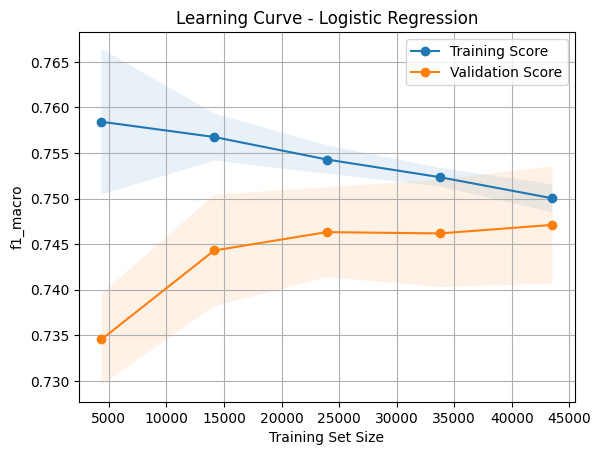

(array([ 4352, 14144, 23936, 33728, 43520]),
 array([0.75842628, 0.75675617, 0.75428783, 0.75235405, 0.75003427]),
 array([0.73455989, 0.74430967, 0.74632735, 0.74617904, 0.74711909]))

In [ ]:
# ---------------------------
# Logistic Regression Training Pipeline
# ---------------------------

pipeline_lr = Pipeline([
    ('prep', preprocessor),
    ('lr', LogisticRegression(max_iter=500))
])

param_grid_lr = {
    'lr__C': np.logspace(-3, 2, 6),
    'lr__solver': ['lbfgs', 'saga'],
    'lr__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_lr = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_grid_lr,
    n_iter=20,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

best_search_lr = timed_fit(
    random_lr,
    X_train,
    y_train,
    model_name="Logistic Regression",
    update_interval=60
)

best_model_lr = best_search_lr.best_estimator_
print("Best Parameters:", random_lr.best_params_)
print("Plotting learning curve")
plot_learning_curve(
    best_model_lr,
    X_train,
    y_train,
    title="Learning Curve - Logistic Regression"
)


Logistic Regression Evaluation Metrics:
Accuracy: 0.821764705882353
Precision: 0.7569671605804413
Recall: 0.7419209820680409
F1 Score: 0.7483146278680071
ROC-AUC: 0.9699808843835703
{'0': {'precision': 0.7481162540365985, 'recall': 0.7861990950226244, 'f1-score': 0.7666850523993382, 'support': 1768.0}, '1': {'precision': 0.8793211816467631, 'recall': 0.8572303921568627, 'f1-score': 0.8681352776915917, 'support': 1632.0}, '2': {'precision': 0.8671439936356404, 'recall': 0.8905228758169934, 'f1-score': 0.8786779524385329, 'support': 4896.0}, '3': {'precision': 0.6360078277886497, 'recall': 0.5974264705882353, 'f1-score': 0.6161137440758294, 'support': 1088.0}, '4': {'precision': 0.5318181818181819, 'recall': 0.43014705882352944, 'f1-score': 0.47560975609756095, 'support': 816.0}, '5': {'precision': 0.8793955245568149, 'recall': 0.89, 'f1-score': 0.8846659845051893, 'support': 3400.0}, 'accuracy': 0.821764705882353, 'macro avg': {'precision': 0.7569671605804413, 'recall': 0.7419209820680

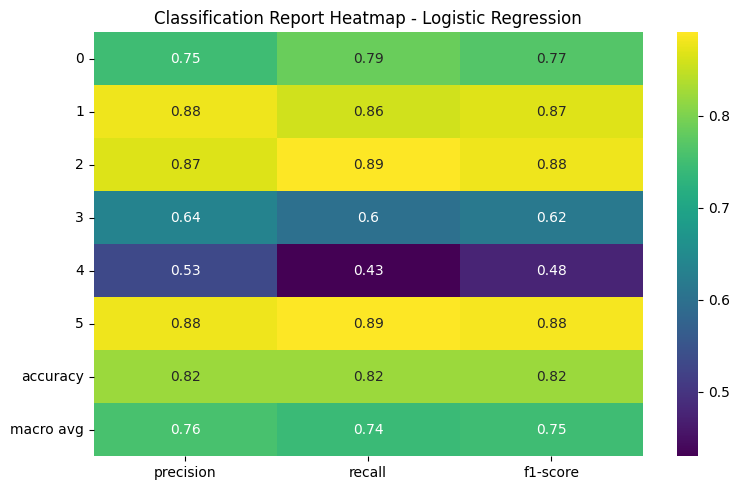

[[1390   60  220   50   44    4]
 [ 123 1399   15   59   34    2]
 [ 103    7 4360    1   17  408]
 [ 120   86   17  650  214    1]
 [ 122   39   42  262  351    0]
 [   0    0  374    0    0 3026]]


<Figure size 640x480 with 0 Axes>

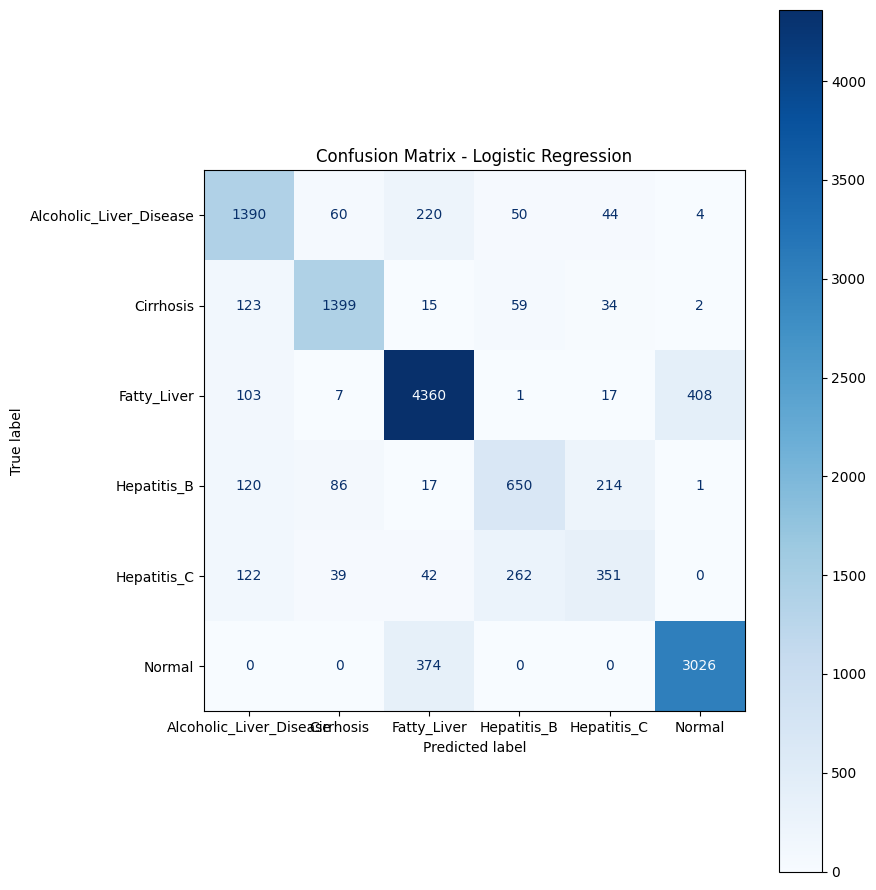

                   feature  importance
21                     AST    0.169118
20                     ALT    0.133279
22               Bilirubin    0.122279
11            Sym_Jaundice    0.047191
15          Sym_Dark_Urine    0.046985
10             Sym_Fatigue    0.045632
23                 Albumin    0.024309
17         Comorb_Diabetes    0.021368
24               Platelets    0.020662
12      Sym_Abdominal_Pain    0.016162
14             Sym_Ascites    0.014603
13             Sym_Itching    0.011000
16         Sym_Weight_Loss    0.004309
19  Comorb_Genetic_History    0.002338
4            Obesity_Class    0.001529
1                   Gender   -0.000059
0                      Age   -0.000147
7              Sleep_Hours   -0.000191
25         Alk_Phosphatase   -0.000206
6        Physical_Activity   -0.000294


<Figure size 640x480 with 0 Axes>

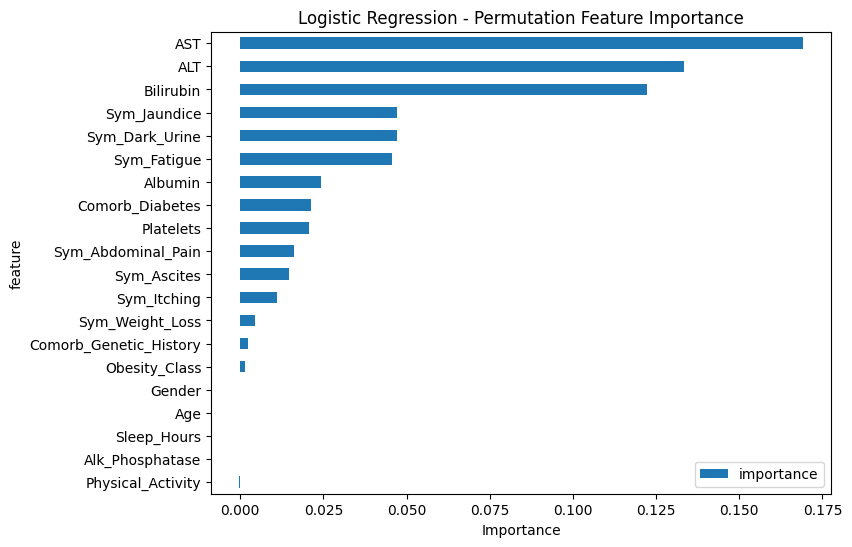

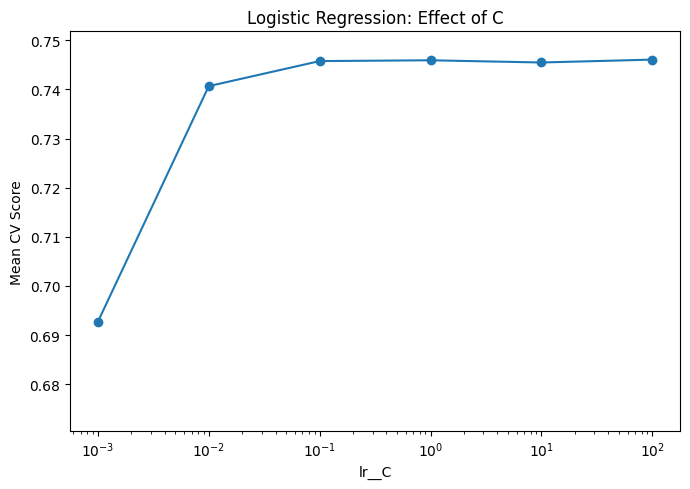

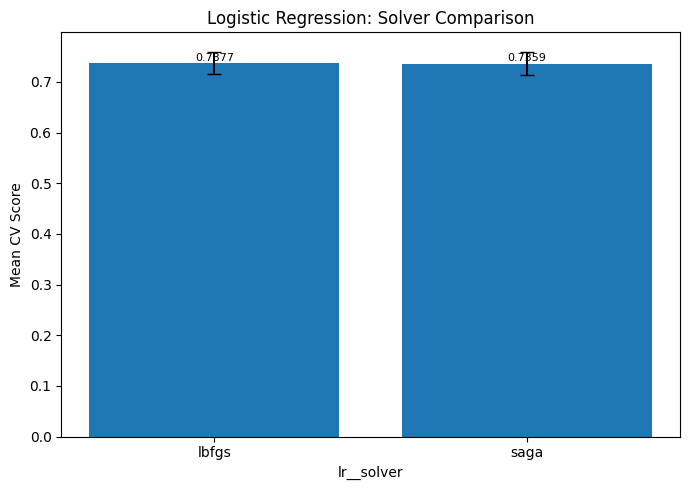

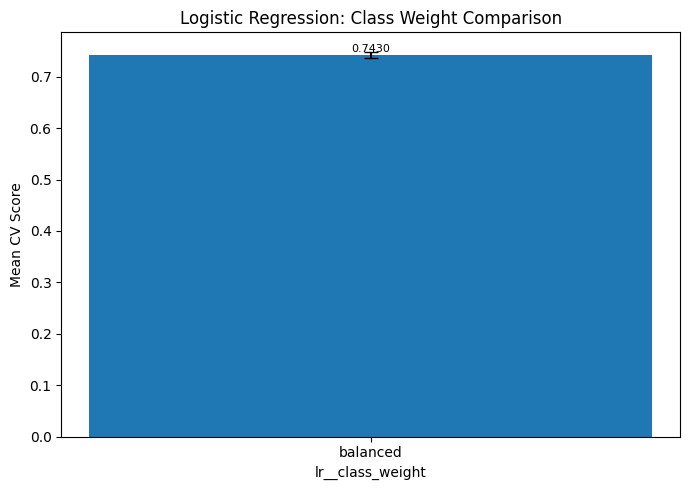

In [ ]:
# ---------------------------
# Logistic Regression Analysis
# ---------------------------

y_pred_lr = best_model_lr.predict(X_test)
y_proba_lr = best_model_lr.predict_proba(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='macro')
recall_lr = recall_score(y_test, y_pred_lr, average='macro')
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
roc_auc_lr = roc_auc_score(y_test, y_proba_lr, multi_class='ovr')

print("\nLogistic Regression Evaluation Metrics:")
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)
print("ROC-AUC:", roc_auc_lr)

# appending to the result array
results.append(
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_lr,
        'Precision': precision_lr,
        'Recall': recall_lr,
        'F1 Score': f1_lr,
        'ROC-AUC': roc_auc_lr
    }
)

perform_classification_analysis(y_test, y_pred_lr, "Logistic Regression")

perform_confusionmatrix_analysis(y_test, y_pred_lr, "Logistic Regression")

perform_feature_importance_analysis(best_model_lr, X_test, y_test, "Logistic Regression")

# ---------------------------
# Hyperparam Analysis
# ---------------------------

plot_hyperparam_analysis(
    grid_search=random_lr,
    param_x='param_lr__C',
    title='Logistic Regression: Effect of C',
    log_x=True,
    kind='line',
    zoom=True
)

plot_hyperparam_analysis(
    grid_search=random_lr,
    param_x='param_lr__solver',
    title='Logistic Regression: Solver Comparison',
    kind='bar',
    show_std=True
)

plot_hyperparam_analysis(
    grid_search=random_lr,
    param_x='param_lr__class_weight',
    title='Logistic Regression: Class Weight Comparison',
    kind='bar',
    show_std=True
)

XGBoost training started: 0:00
XGBoost total training time: 0:24
Best Parameters: {'xgb__subsample': 1.0, 'xgb__n_estimators': 300, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 0.8}
Plotting learning curve


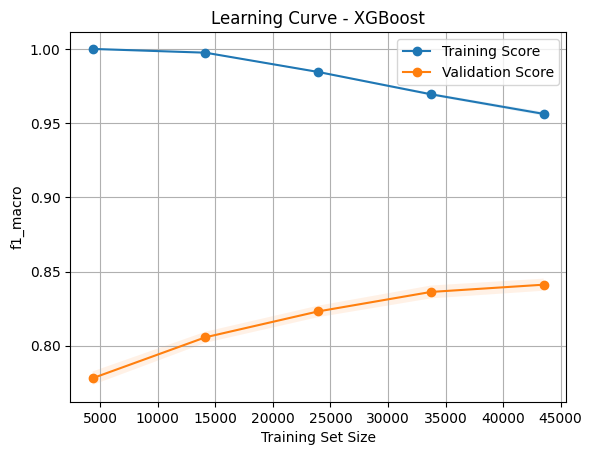

(array([ 4352, 14144, 23936, 33728, 43520]),
 array([1.        , 0.99746631, 0.9844774 , 0.96944606, 0.95623438]),
 array([0.77817645, 0.80572189, 0.82315291, 0.83626539, 0.84115476]))

In [ ]:
# ---------------------------
# XGBoost Training Pipeline
# ---------------------------

from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ('prep', preprocessor),
    ('xgb', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=RANDOM_STATE
    ))
])

param_grid_xgb = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

random_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

best_search_xgb = timed_fit(
    random_xgb,
    X_train,
    y_train,
    model_name="XGBoost",
    update_interval=60
)

best_model_xgb = best_search_xgb.best_estimator_
print("Best Parameters:", random_xgb.best_params_)
print("Plotting learning curve")
plot_learning_curve(
    best_model_xgb,
    X_train,
    y_train,
    title="Learning Curve - XGBoost"
)


XGBoost Evaluation Metrics:
Accuracy: 0.8883823529411765
Precision: 0.8588817563565875
Recall: 0.8435450184347243
F1 Score: 0.8506174285535028
ROC-AUC: 0.9877815942299984
{'0': {'precision': 0.8262506724045185, 'recall': 0.8687782805429864, 'f1-score': 0.8469809760132341, 'support': 1768.0}, '1': {'precision': 0.9519168291098116, 'recall': 0.897671568627451, 'f1-score': 0.923998738568275, 'support': 1632.0}, '2': {'precision': 0.9155752569010679, 'recall': 0.9281045751633987, 'f1-score': 0.9217973425296683, 'support': 4896.0}, '3': {'precision': 0.8331688055281342, 'recall': 0.7757352941176471, 'f1-score': 0.803426939552594, 'support': 1088.0}, '4': {'precision': 0.7188328912466844, 'recall': 0.6642156862745098, 'f1-score': 0.6904458598726114, 'support': 816.0}, '5': {'precision': 0.9075460829493087, 'recall': 0.9267647058823529, 'f1-score': 0.9170547147846333, 'support': 3400.0}, 'accuracy': 0.8883823529411765, 'macro avg': {'precision': 0.8588817563565875, 'recall': 0.84354501843472

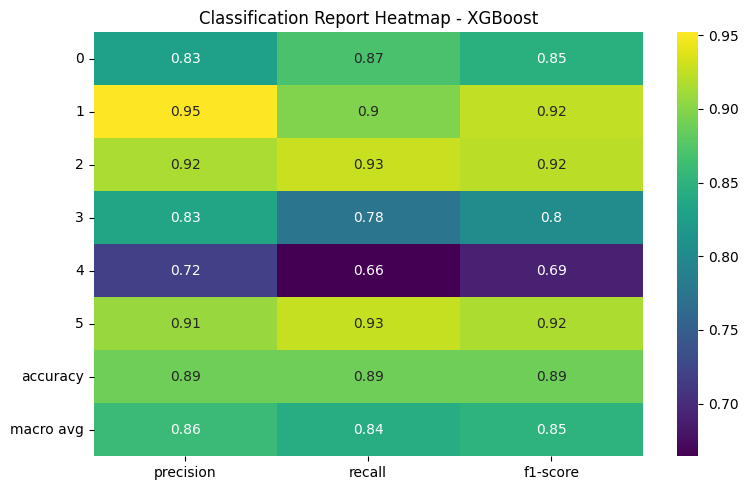

[[1536   22  133   18   58    1]
 [  98 1465    4   42   23    0]
 [  25    2 4544    0    6  319]
 [  75   30   14  844  125    0]
 [ 124   20   20  109  542    1]
 [   1    0  248    0    0 3151]]


<Figure size 640x480 with 0 Axes>

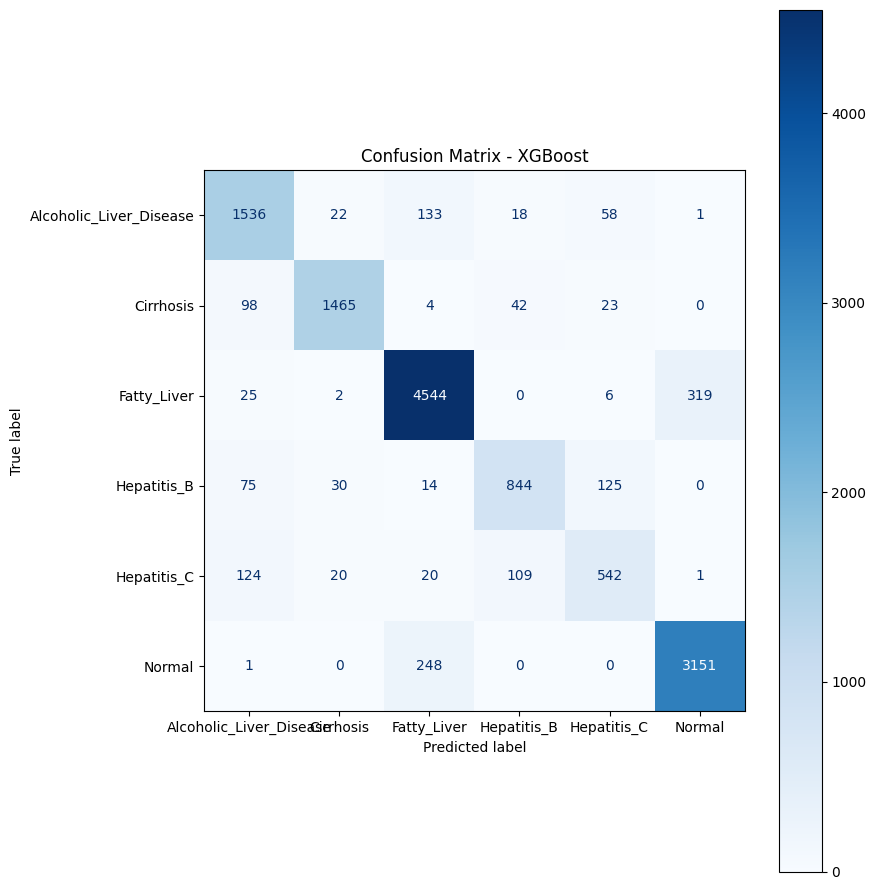

                   feature  importance
22               Bilirubin    0.225529
21                     AST    0.179206
20                     ALT    0.169838
23                 Albumin    0.108015
24               Platelets    0.053265
11            Sym_Jaundice    0.039029
15          Sym_Dark_Urine    0.035515
10             Sym_Fatigue    0.032779
17         Comorb_Diabetes    0.014324
14             Sym_Ascites    0.012132
12      Sym_Abdominal_Pain    0.010338
13             Sym_Itching    0.007559
16         Sym_Weight_Loss    0.002088
19  Comorb_Genetic_History    0.001309
1                   Gender    0.000529
18     Comorb_Hypertension    0.000426
8           Smoking_Status    0.000103
4            Obesity_Class   -0.000059
9      Alcohol_Consumption   -0.000176
7              Sleep_Hours   -0.000235


<Figure size 640x480 with 0 Axes>

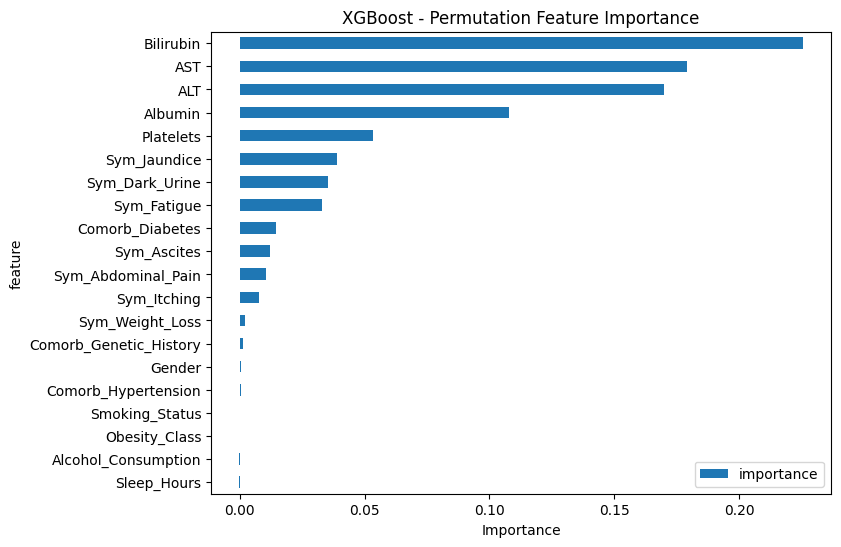

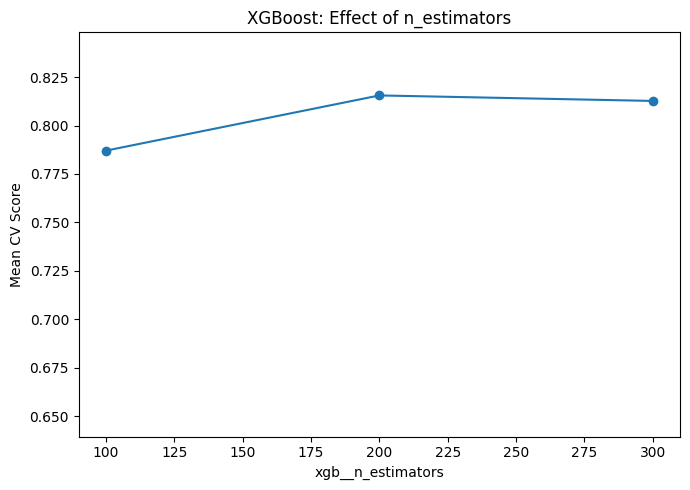

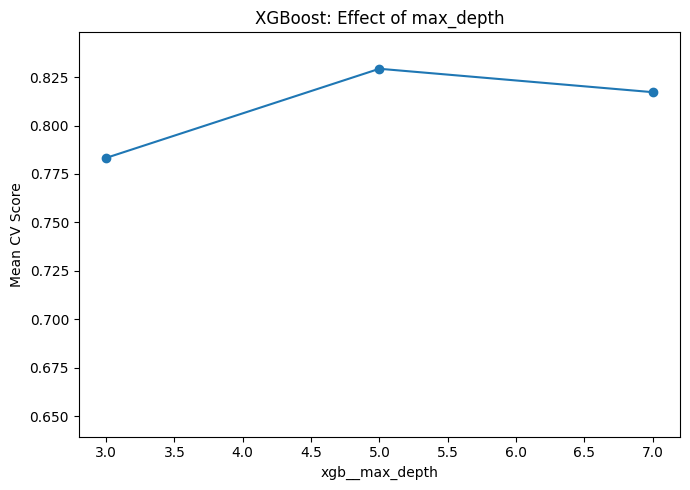

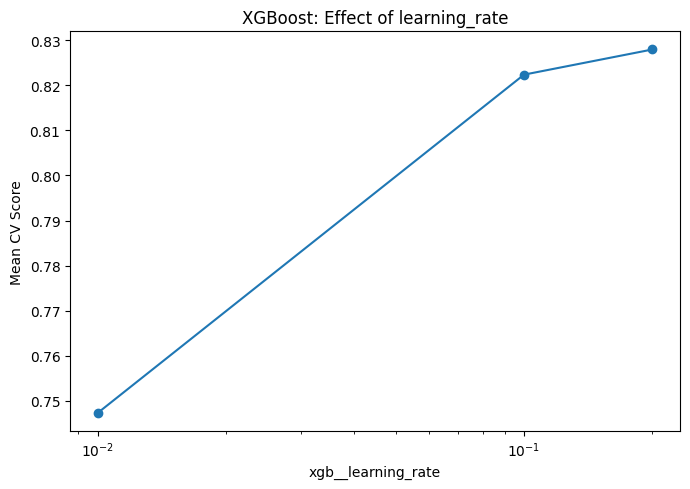

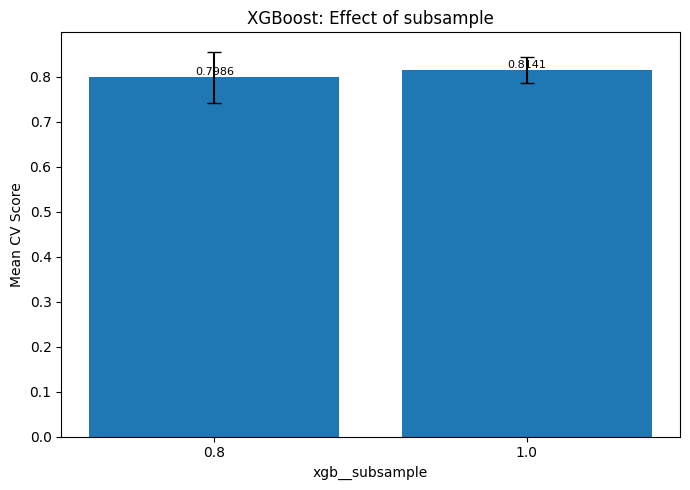

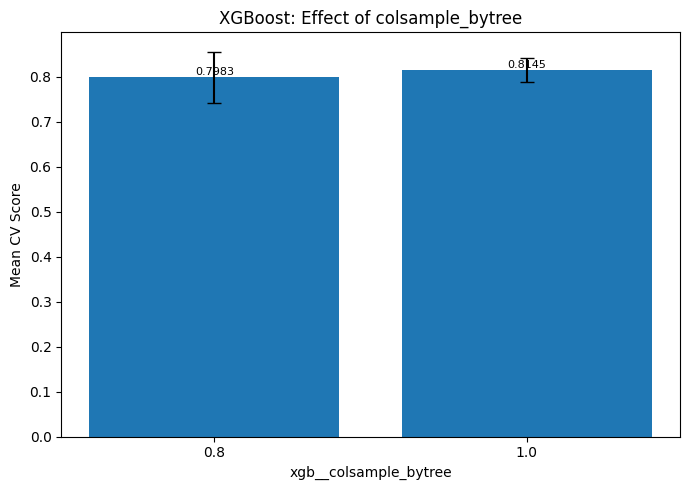

In [ ]:
# ---------------------------
# XGBoost Analysis
# ---------------------------

y_pred_xgb = best_model_xgb.predict(X_test)
y_proba_xgb = best_model_xgb.predict_proba(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='macro')
recall_xgb = recall_score(y_test, y_pred_xgb, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr')

print("\nXGBoost Evaluation Metrics:")
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)
print("ROC-AUC:", roc_auc_xgb)

# appending to the results array
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_xgb,
    'Precision': precision_xgb,
    'Recall': recall_xgb,
    'F1 Score': f1_xgb,
    'ROC-AUC': roc_auc_xgb
})

perform_classification_analysis(y_test, y_pred_xgb, "XGBoost")

perform_confusionmatrix_analysis(y_test, y_pred_xgb, "XGBoost")

# You can reuse your permutation importance function (works well here)
perform_feature_importance_analysis(best_model_xgb, X_test, y_test, "XGBoost")

# ---------------------------
# Hyperparam Analysis
# ---------------------------

plot_hyperparam_analysis(
    random_xgb,
    param_x='param_xgb__n_estimators',
    title='XGBoost: Effect of n_estimators',
    kind='line',
    zoom=True
)

plot_hyperparam_analysis(
    random_xgb,
    param_x='param_xgb__max_depth',
    title='XGBoost: Effect of max_depth',
    kind='line',
    zoom=True
)

plot_hyperparam_analysis(
    random_xgb,
    param_x='param_xgb__learning_rate',
    title='XGBoost: Effect of learning_rate',
    log_x=True,
    kind='line'
)

plot_hyperparam_analysis(
    random_xgb,
    param_x='param_xgb__subsample',
    title='XGBoost: Effect of subsample',
    kind='bar',
    show_std=True
)

plot_hyperparam_analysis(
    random_xgb,
    param_x='param_xgb__colsample_bytree',
    title='XGBoost: Effect of colsample_bytree',
    kind='bar',
    show_std=True
)

### Saketh

MLP training started: 0:00
Fitting 5 folds for each of 20 candidates, totalling 100 fits
MLP training time: 1:00
MLP total training time: 1:15
Best Parameters: {'mlp__learning_rate_init': 0.01, 'mlp__learning_rate': 'adaptive', 'mlp__hidden_layer_sizes': (256, 128, 64), 'mlp__alpha': np.float64(0.01), 'mlp__activation': 'relu'}
Best CV Score: 0.7771191438379965


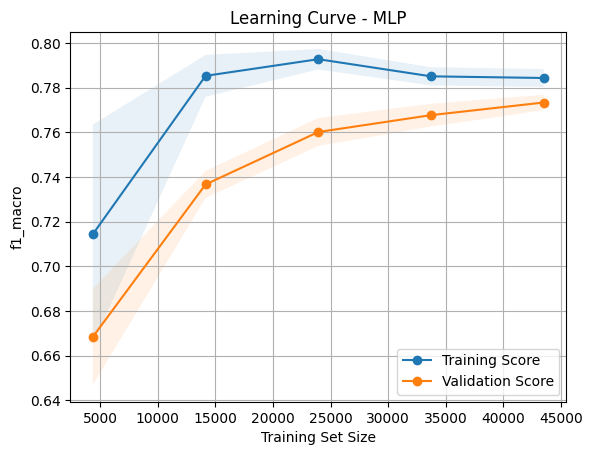

(array([ 4352, 14144, 23936, 33728, 43520]),
 array([0.71435612, 0.78523419, 0.79269434, 0.78502192, 0.78427863]),
 array([0.66840404, 0.73663142, 0.76010056, 0.76765226, 0.77330635]))

In [ ]:
# ---------------------------
# MLP Training
# ---------------------------

pipeline_mlp = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        solver='adam',
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ))
])

param_dist_mlp = {
    'mlp__hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': np.logspace(-3, -1, 3),
    'mlp__learning_rate_init': [0.001, 0.01],
    'mlp__learning_rate': ['constant', 'adaptive']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_mlp = RandomizedSearchCV(
    pipeline_mlp,
    param_distributions=param_dist_mlp,
    n_iter=20,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

best_search_mlp = timed_fit(
    random_mlp,
    X_train,
    y_train,
    model_name="MLP",
    update_interval=60
)

best_model_mlp = best_search_mlp.best_estimator_

print("Best Parameters:", random_mlp.best_params_)
print("Best CV Score:", random_mlp.best_score_)

# Learning Curve
plot_learning_curve(
    best_model_mlp,
    X_train,
    y_train,
    title="Learning Curve - MLP"
)


MLP Evaluation Metrics:
Accuracy: 0.8416176470588236
Precision: 0.7900767707814732
Recall: 0.7656715581531759
F1 Score: 0.7742920477020809
ROC-AUC: 0.9759321745070801
{'0': {'precision': 0.8086560364464692, 'recall': 0.8031674208144797, 'f1-score': 0.8059023836549376, 'support': 1768.0}, '1': {'precision': 0.9111969111969112, 'recall': 0.8676470588235294, 'f1-score': 0.8888888888888888, 'support': 1632.0}, '2': {'precision': 0.8768715524034673, 'recall': 0.909109477124183, 'f1-score': 0.8926995587645408, 'support': 4896.0}, '3': {'precision': 0.738562091503268, 'recall': 0.5193014705882353, 'f1-score': 0.6098219104155423, 'support': 1088.0}, '4': {'precision': 0.5269058295964125, 'recall': 0.5759803921568627, 'f1-score': 0.550351288056206, 'support': 816.0}, '5': {'precision': 0.8782682035423109, 'recall': 0.9188235294117647, 'f1-score': 0.8980882564323702, 'support': 3400.0}, 'accuracy': 0.8416176470588236, 'macro avg': {'precision': 0.7900767707814732, 'recall': 0.7656715581531759, 

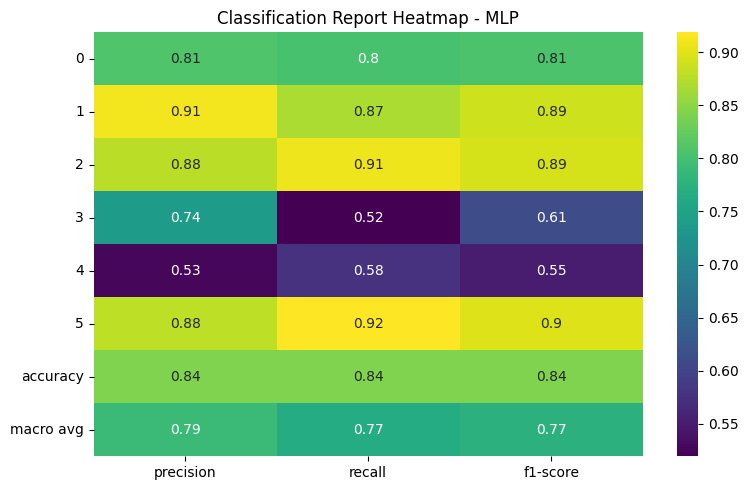

[[1420   34  238   22   53    1]
 [ 120 1416   17   31   47    1]
 [   9    3 4451    0    3  430]
 [  95   74   35  565  319    0]
 [ 112   27   59  147  470    1]
 [   0    0  276    0    0 3124]]


<Figure size 640x480 with 0 Axes>

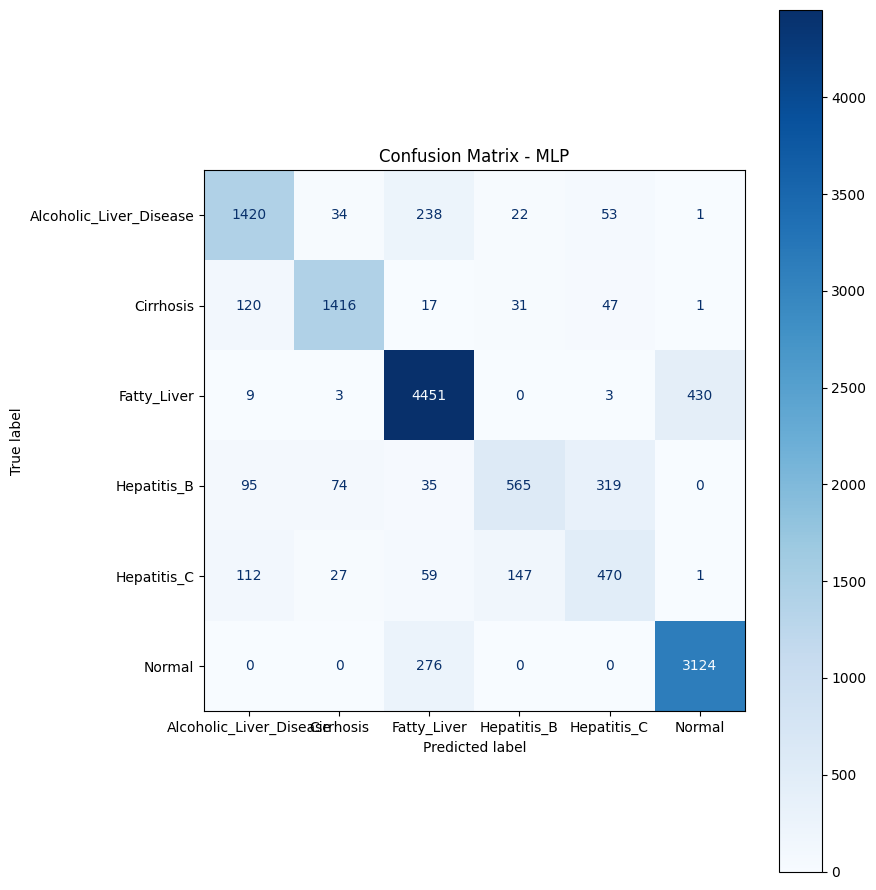

                   feature    importance
22               Bilirubin  1.976912e-01
21                     AST  1.574118e-01
20                     ALT  1.278529e-01
23                 Albumin  9.423529e-02
24               Platelets  5.004412e-02
15          Sym_Dark_Urine  4.302941e-02
11            Sym_Jaundice  3.895588e-02
10             Sym_Fatigue  3.677941e-02
17         Comorb_Diabetes  1.736765e-02
12      Sym_Abdominal_Pain  1.357353e-02
14             Sym_Ascites  1.183824e-02
13             Sym_Itching  1.175000e-02
16         Sym_Weight_Loss  3.338235e-03
19  Comorb_Genetic_History  1.235294e-03
25         Alk_Phosphatase  1.470588e-04
1                   Gender  4.440892e-17
8           Smoking_Status -1.323529e-04
18     Comorb_Hypertension -2.205882e-04
9      Alcohol_Consumption -3.088235e-04
4            Obesity_Class -3.088235e-04


<Figure size 640x480 with 0 Axes>

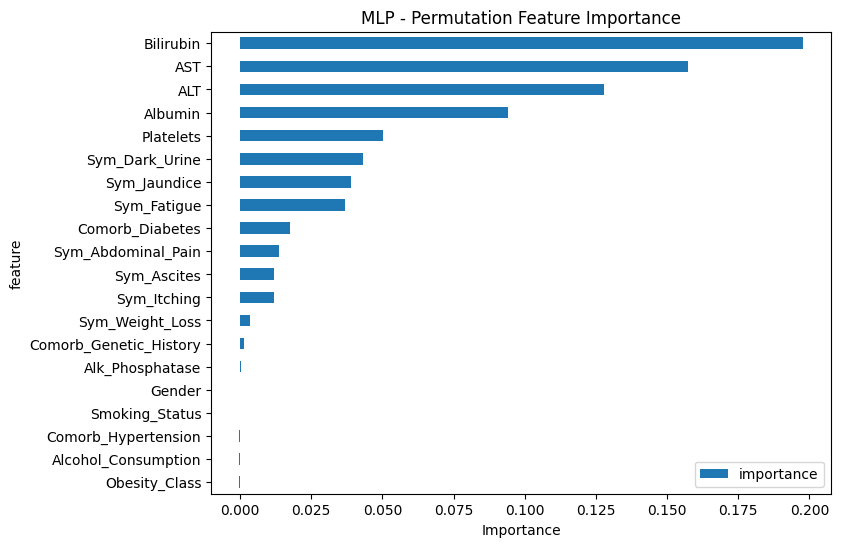

In [ ]:
# ---------------------------
# MLP Analysis
# ---------------------------

y_pred_mlp = best_model_mlp.predict(X_test)
y_proba_mlp = best_model_mlp.predict_proba(X_test)

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp, average='macro')
recall_mlp = recall_score(y_test, y_pred_mlp, average='macro')
f1_mlp = f1_score(y_test, y_pred_mlp, average='macro')
roc_auc_mlp = roc_auc_score(y_test, y_proba_mlp, multi_class='ovr')

print("\nMLP Evaluation Metrics:")
print("Accuracy:", accuracy_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)
print("F1 Score:", f1_mlp)
print("ROC-AUC:", roc_auc_mlp)

# appending to the results array
results.append(
    {
        'Model': 'MLP',
        'Accuracy': accuracy_mlp,
        'Precision': precision_mlp,
        'Recall': recall_mlp,
        'F1 Score': f1_mlp,
        'ROC-AUC': roc_auc_mlp
    }
)

perform_classification_analysis(y_test, y_pred_mlp, "MLP")

perform_confusionmatrix_analysis(y_test, y_pred_mlp, "MLP")

perform_feature_importance_analysis(best_model_mlp, X_test, y_test, "MLP")

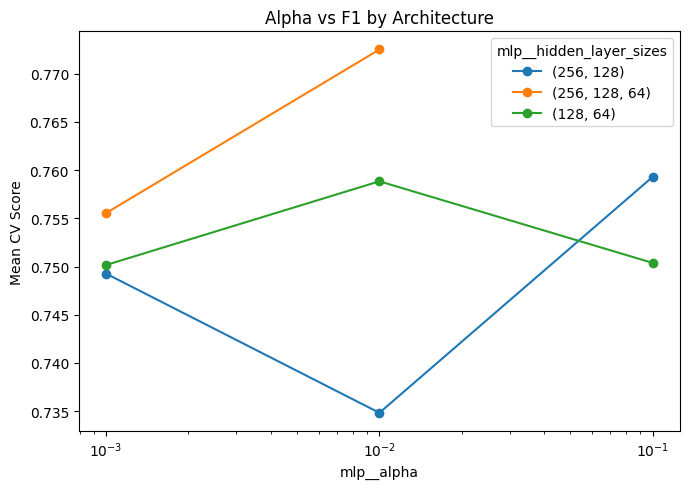

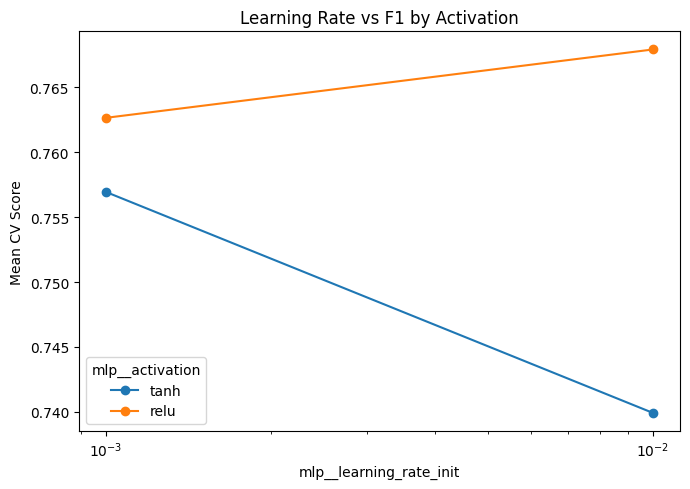

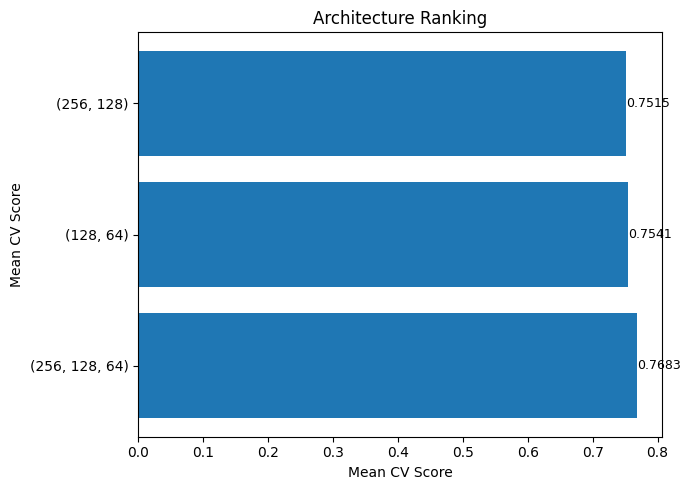

In [ ]:
plot_hyperparam_analysis(
    random_mlp,
    param_x='param_mlp__alpha',
    param_group='param_mlp__hidden_layer_sizes',
    title='Alpha vs F1 by Architecture',
    log_x=True
)

plot_hyperparam_analysis(
    random_mlp,
    param_x='param_mlp__learning_rate_init',
    param_group='param_mlp__activation',
    title='Learning Rate vs F1 by Activation',
    log_x=True
)

plot_hyperparam_analysis(
    random_mlp,
    param_x='param_mlp__hidden_layer_sizes',
    title='Architecture Ranking',
    rank=True
)

### Krishna

KNN training started: 0:00
Fitting 5 folds for each of 24 candidates, totalling 120 fits
KNN total training time: 0:23
Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 18, 'knn__weights': 'distance'}
Best CV Score: 0.6460303047175737


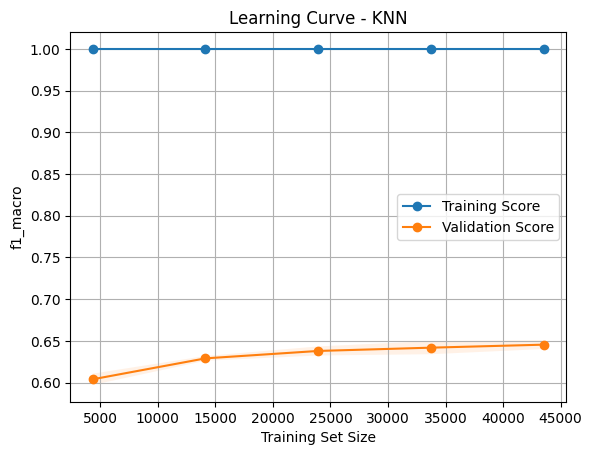

(array([ 4352, 14144, 23936, 33728, 43520]),
 array([1., 1., 1., 1., 1.]),
 array([0.6038721 , 0.62895123, 0.63783928, 0.64178104, 0.64538152]))

In [ ]:
# Krishna - kNN
#     For 2-21-2, it took 35min

# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), numerical_cols),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), non_bin_cat_cols),
#     ('bin', 'passthrough', binary_cols)
# ])

pipeline_kNN = Pipeline([
    ('prep', preprocessor),
    ('knn', KNeighborsClassifier())
])

param_grid_kNN = {
    'knn__n_neighbors': list(range(3, 19, 3)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_kNN = GridSearchCV(
    pipeline_kNN,
    param_grid_kNN,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3
)

best_search_kNN = timed_fit(
    grid_kNN,
    X_train,
    y_train,
    model_name="KNN",
    update_interval=60
)

best_model = best_search_kNN.best_estimator_

print("Best Parameters:", grid_kNN.best_params_)
print("Best CV Score:", grid_kNN.best_score_)

# Learning Curve
plot_learning_curve(
    best_model,
    X_train,
    y_train,
    title="Learning Curve - KNN"
)

Best Train Score:  1.0
Best Test Score:   0.6432529997087073
Accuracy Score:    0.738014705882353
Precision score:   0.6865433402182735
Recall score:      0.6240392471091001
F1 score:          0.6432529997087073
ROC-AUC:           0.9341350613168551
{'0': {'precision': 0.5902075572112826, 'recall': 0.627262443438914, 'f1-score': 0.6081710995338635, 'support': 1768.0}, '1': {'precision': 0.9076669414674361, 'recall': 0.6746323529411765, 'f1-score': 0.7739894551845343, 'support': 1632.0}, '2': {'precision': 0.7690222652468538, 'recall': 0.8112745098039216, 'f1-score': 0.7895835404035384, 'support': 4896.0}, '3': {'precision': 0.6296758104738155, 'recall': 0.4641544117647059, 'f1-score': 0.5343915343915344, 'support': 1088.0}, '4': {'precision': 0.45560747663551404, 'recall': 0.23897058823529413, 'f1-score': 0.3135048231511254, 'support': 816.0}, '5': {'precision': 0.7670799902747386, 'recall': 0.9279411764705883, 'f1-score': 0.839877545587648, 'support': 3400.0}, 'accuracy': 0.7380147058

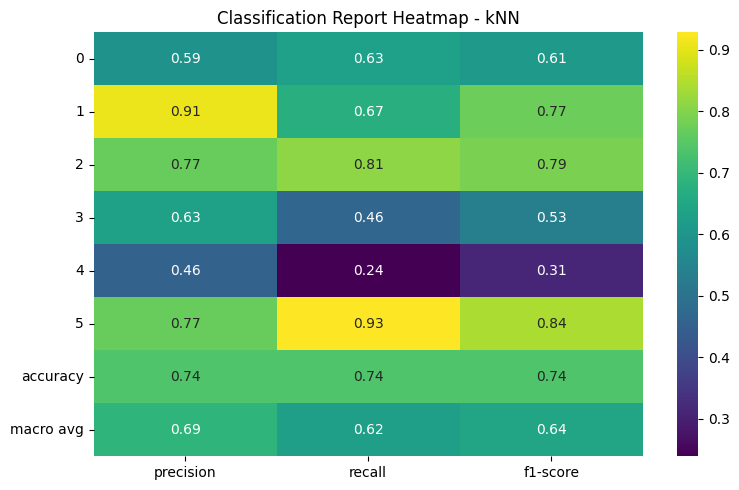

[[1109   32  557   23   19   28]
 [ 332 1101  132   41   21    5]
 [   8    0 3972    0    0  916]
 [ 225   65   97  505  193    3]
 [ 205   15  162  233  195    6]
 [   0    0  245    0    0 3155]]


<Figure size 640x480 with 0 Axes>

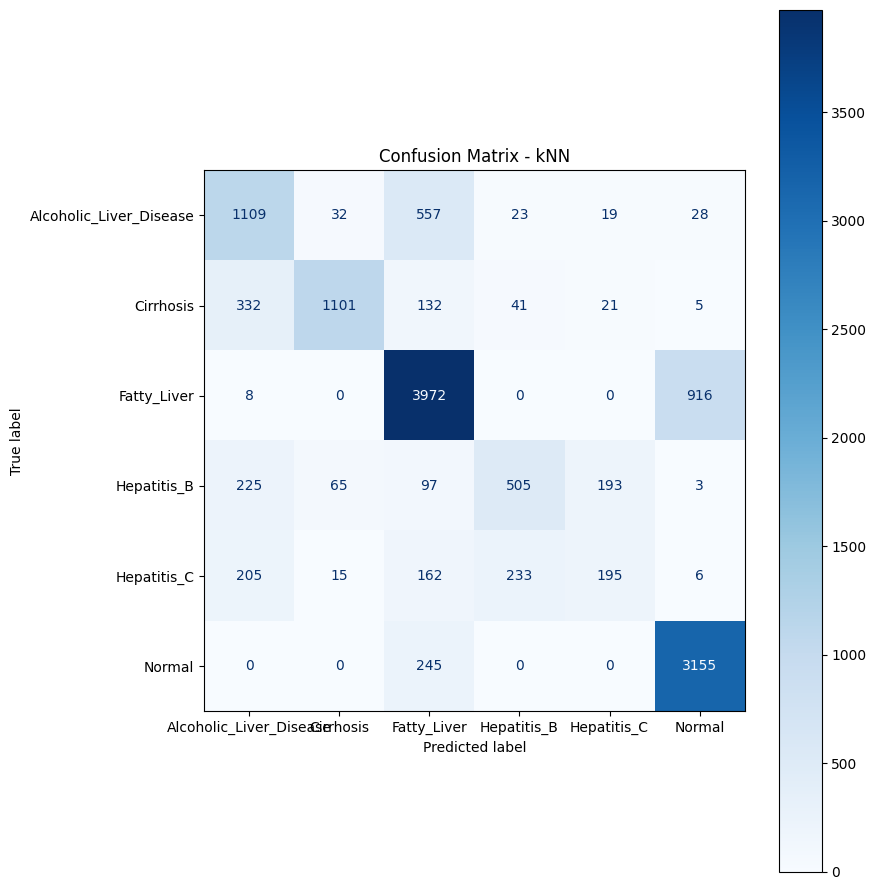

                   feature  importance
21                     AST    0.121471
20                     ALT    0.116838
22               Bilirubin    0.104544
10             Sym_Fatigue    0.042074
15          Sym_Dark_Urine    0.030912
23                 Albumin    0.030838
11            Sym_Jaundice    0.029265
24               Platelets    0.024235
17         Comorb_Diabetes    0.019809
12      Sym_Abdominal_Pain    0.011529
14             Sym_Ascites    0.007632
16         Sym_Weight_Loss    0.003838
13             Sym_Itching    0.003824
19  Comorb_Genetic_History    0.001294
25         Alk_Phosphatase    0.000941
1                   Gender    0.000882
9      Alcohol_Consumption    0.000074
6        Physical_Activity    0.000059
18     Comorb_Hypertension   -0.000426
0                      Age   -0.001397


<Figure size 640x480 with 0 Axes>

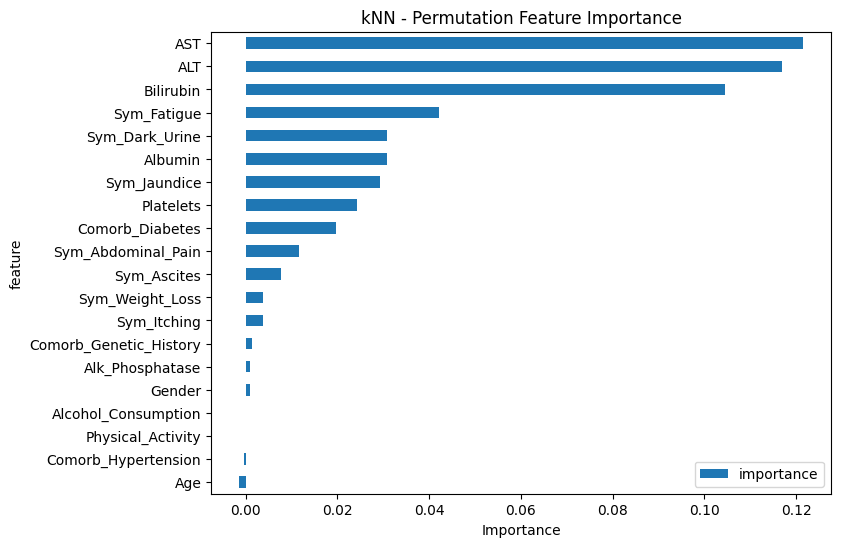

In [ ]:
#19 kNN - Analysis

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

accuracy_kNN = accuracy_score(y_test, y_pred)
precision_kNN = precision_score(y_test, y_pred, average='macro')
recall_kNN = recall_score(y_test, y_pred, average='macro')
f1_kNN = f1_score(y_test, y_pred, average='macro')
roc_auc_kNN = roc_auc_score(y_test, y_proba, multi_class='ovr')

print("Best Train Score: ", grid_kNN.score(X_train, y_train))
print("Best Test Score:  ", grid_kNN.score(X_test, y_test))
print("Accuracy Score:   ", accuracy_kNN)
print("Precision score:  ", precision_kNN)
print("Recall score:     ", recall_kNN)
print("F1 score:         ", f1_kNN)
print("ROC-AUC:          ", roc_auc_kNN)

# append to results array
results.append(
    {
        'Model': 'kNN',
        'Accuracy': accuracy_kNN,
        'Precision': precision_kNN,
        'Recall': recall_kNN,
        'F1 Score': f1_kNN,
        'ROC-AUC': roc_auc_kNN
    }
)

perform_classification_analysis(y_test, y_pred, "kNN")

perform_confusionmatrix_analysis(y_test, y_pred, "kNN")

perform_feature_importance_analysis(best_model, X_test, y_test, "kNN")


Random Forest training started: 0:00
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest total training time: 0:34
Best Parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_depth': 20, 'rf__criterion': 'gini'}
Best CV Score: 0.8541728068594739


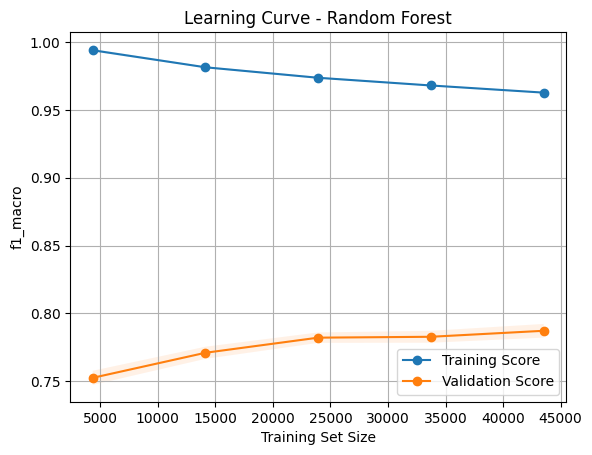

(array([ 4352, 14144, 23936, 33728, 43520]),
 array([0.99403986, 0.98147193, 0.97373228, 0.96805367, 0.96278442]),
 array([0.75243589, 0.77092102, 0.78206624, 0.78271393, 0.7871355 ]))

In [ ]:
#20 Random Forest
# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), numerical_cols),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), non_bin_cat_cols),
#     ('bin', 'passthrough', binary_cols)
# ])

pipeline_rf = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE))
])

# -----------------------------
# Hyperparameter grid
# -----------------------------
param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__criterion': ['gini', 'entropy']
}

# -----------------------------
# K-Fold setup
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# -----------------------------
# Grid Search
# -----------------------------
# grid = GridSearchCV(model, param_grid, cv=cv,
#                     scoring='f1_macro', n_jobs=-1, verbose=2)
X_train.columns
grid_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_grid_rf,
    n_iter=30,
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE
)
# -----------------------------
# Train
# -----------------------------
best_search_rf = timed_fit(
    grid_rf,
    X_train,
    y_train,
    model_name="Random Forest",
    update_interval=60
)

# -----------------------------
# Results
# -----------------------------
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

best_model_rf = best_search_rf.best_estimator_

# Learning Curve
plot_learning_curve(
    best_model_rf,
    X_train,
    y_train,
    title="Learning Curve - Random Forest"
)


Best Train Score:  0.9569669117647058
Best Test Score:   0.8575
Accuracy Score:    0.8575
Precision score:   0.8026211265647265
Recall score:      0.7809976223395342
F1 score:          0.7903115896874257
ROC-AUC:           0.9767478455899351
{'0': {'precision': 0.8038585209003215, 'recall': 0.8484162895927602, 'f1-score': 0.825536598789213, 'support': 1768.0}, '1': {'precision': 0.9183544303797468, 'recall': 0.8890931372549019, 'f1-score': 0.9034869240348692, 'support': 1632.0}, '2': {'precision': 0.8880684026428294, 'recall': 0.9334150326797386, 'f1-score': 0.9101772555267875, 'support': 4896.0}, '3': {'precision': 0.7249443207126949, 'recall': 0.5983455882352942, 'f1-score': 0.6555891238670695, 'support': 1088.0}, '4': {'precision': 0.5708446866485014, 'recall': 0.5134803921568627, 'f1-score': 0.5406451612903226, 'support': 816.0}, '5': {'precision': 0.9096563981042654, 'recall': 0.903235294117647, 'f1-score': 0.9064344746162928, 'support': 3400.0}, 'accuracy': 0.8575, 'macro avg': {

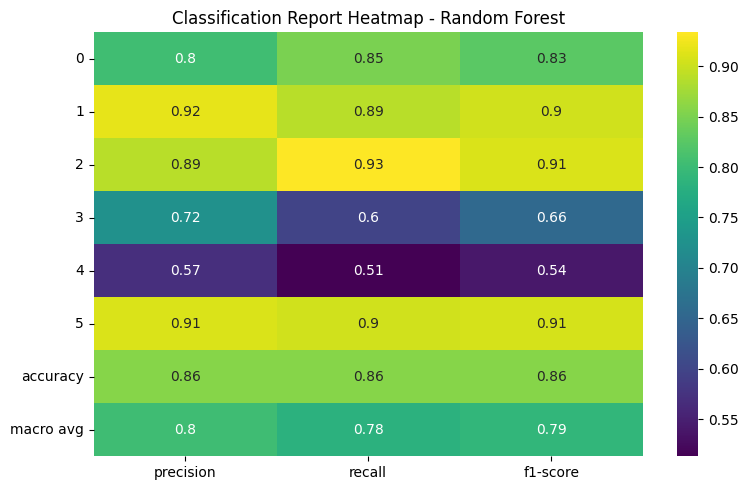

[[1500   42  168   19   38    1]
 [  99 1451   13   38   31    0]
 [  16    0 4570    0    7  303]
 [ 112   60   26  651  239    0]
 [ 139   27   40  190  419    1]
 [   0    0  329    0    0 3071]]


<Figure size 640x480 with 0 Axes>

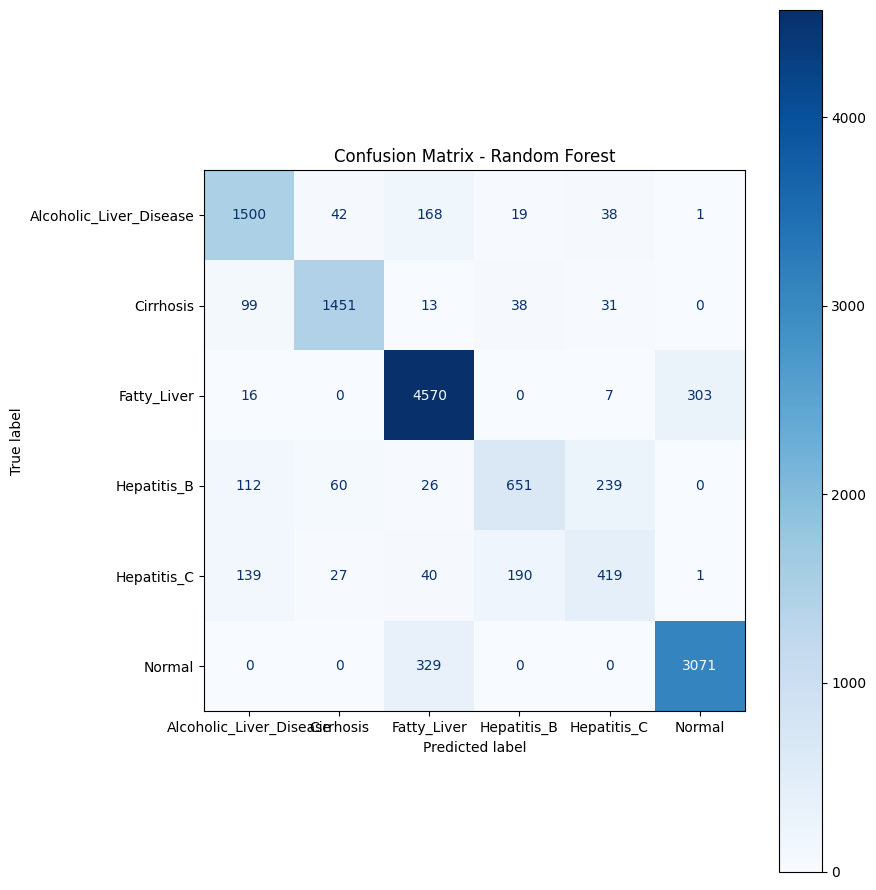

                   feature  importance
22               Bilirubin    0.215647
21                     AST    0.177250
20                     ALT    0.129015
23                 Albumin    0.082132
24               Platelets    0.053868
15          Sym_Dark_Urine    0.049721
11            Sym_Jaundice    0.047471
10             Sym_Fatigue    0.039721
14             Sym_Ascites    0.014544
17         Comorb_Diabetes    0.014279
12      Sym_Abdominal_Pain    0.011912
13             Sym_Itching    0.008882
16         Sym_Weight_Loss    0.002294
3                      BMI    0.000897
19  Comorb_Genetic_History    0.000294
4            Obesity_Class    0.000044
9      Alcohol_Consumption   -0.000191
8           Smoking_Status   -0.000206
18     Comorb_Hypertension   -0.000426
6        Physical_Activity   -0.000485


<Figure size 640x480 with 0 Axes>

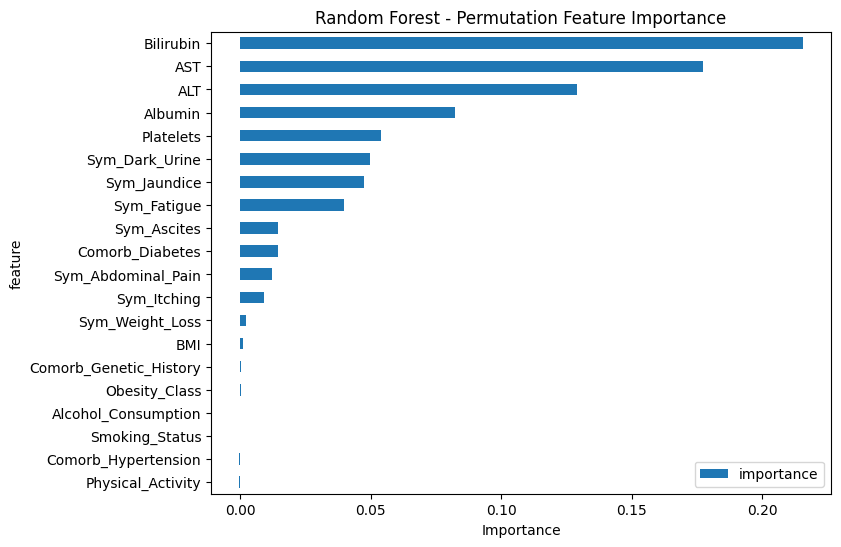

In [ ]:
# Random Forest - Analysis

y_pred = best_model_rf.predict(X_test)
y_proba = best_model_rf.predict_proba(X_test)

accuracy_rf = accuracy_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred, average='macro')
recall_rf = recall_score(y_test, y_pred, average='macro')
f1_rf = f1_score(y_test, y_pred, average='macro')
roc_auc_rf = roc_auc_score(y_test, y_proba, multi_class='ovr')

print("Best Train Score: ", grid_rf.score(X_train, y_train))
print("Best Test Score:  ", grid_rf.score(X_test, y_test))
print("Accuracy Score:   ", accuracy_rf)
print("Precision score:  ", precision_rf)
print("Recall score:     ", recall_rf)
print("F1 score:         ", f1_rf)
print("ROC-AUC:          ", roc_auc_rf)

# appending to the results array
results.append({
    'Model': 'Random Forest (cv=3)',
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1 Score': f1_rf,
    'ROC-AUC': roc_auc_rf
})

perform_classification_analysis(y_test, y_pred, "Random Forest")

perform_confusionmatrix_analysis(y_test, y_pred, "Random Forest")

perform_feature_importance_analysis(best_model_rf, X_test, y_test, "Random Forest")


Random Forest (Corrected - 5 fold CV) training started: 0:00
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest (Corrected - 5 fold CV) total training time: 0:52
Best Parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_depth': None, 'rf__criterion': 'gini'}
Best CV Score: 0.8538051470588236


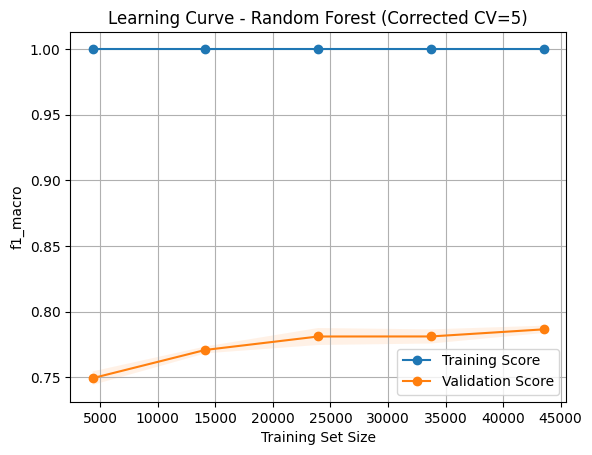

(array([ 4352, 14144, 23936, 33728, 43520]),
 array([1., 1., 1., 1., 1.]),
 array([0.74948537, 0.77096758, 0.78117517, 0.78120815, 0.78661396]))

In [ ]:
# =============================================
# Training Random Forest with PROPER CV (5-fold)
# =============================================

pipeline_rf_new = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE))
])

# -----------------------------
# Hyperparameter grid
# -----------------------------
param_grid_rf_new = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__criterion': ['gini', 'entropy']
}

# -----------------------------
# K-Fold setup
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# -----------------------------
# Randomized Search with correct CV
# -----------------------------
grid_rf_new = RandomizedSearchCV(
    pipeline_rf_new,
    param_distributions=param_grid_rf_new,
    n_iter=30,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE
)

# -----------------------------
# Train the model
# -----------------------------
best_search_rf_new = timed_fit(
    grid_rf_new,
    X_train,
    y_train,
    model_name="Random Forest (Corrected - 5 fold CV)",
    update_interval=60
)

# -----------------------------
# Results
# -----------------------------
print("Best Parameters:", grid_rf_new.best_params_)
print("Best CV Score:", grid_rf_new.best_score_)

best_model_rf_new = best_search_rf_new.best_estimator_

# Learning Curve
plot_learning_curve(
    best_model_rf_new,
    X_train,
    y_train,
    title="Learning Curve - Random Forest (Corrected CV=5)"
)

Best Train Score:  1.0
Best Test Score:   0.8597794117647058
Accuracy Score:    0.8597794117647058
Precision score:   0.8028349268292367
Recall score:      0.7823263365175129
F1 score:          0.7912945990112062
ROC-AUC:           0.9760513392689578
{'0': {'precision': 0.8079186730872124, 'recall': 0.8540723981900452, 'f1-score': 0.8303546879296123, 'support': 1768.0}, '1': {'precision': 0.9204834605597965, 'recall': 0.8866421568627451, 'f1-score': 0.9032459425717853, 'support': 1632.0}, '2': {'precision': 0.892244738893219, 'recall': 0.9352532679738562, 'f1-score': 0.9132429198244915, 'support': 4896.0}, '3': {'precision': 0.7066246056782335, 'recall': 0.6176470588235294, 'f1-score': 0.6591466405100539, 'support': 1088.0}, '4': {'precision': 0.5773638968481375, 'recall': 0.49387254901960786, 'f1-score': 0.5323645970937912, 'support': 816.0}, '5': {'precision': 0.9123741859088218, 'recall': 0.9064705882352941, 'f1-score': 0.9094128061375036, 'support': 3400.0}, 'accuracy': 0.859779411

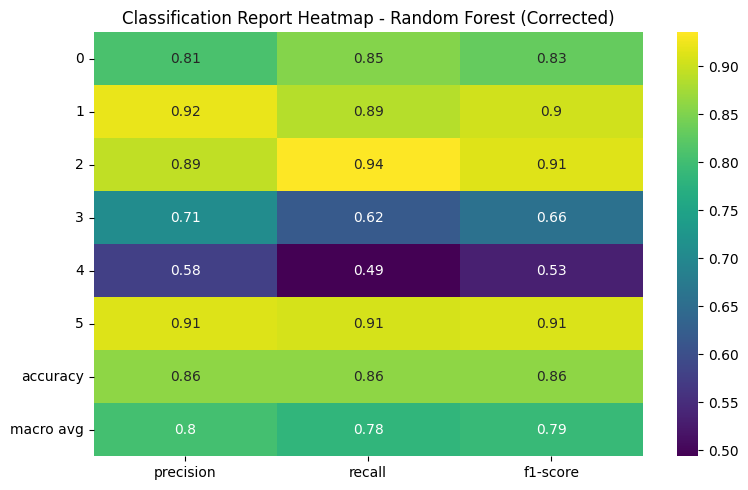

[[1510   41  158   25   33    1]
 [  98 1447   14   42   31    0]
 [  16    0 4579    0    7  294]
 [ 109   57   26  672  224    0]
 [ 136   27   37  212  403    1]
 [   0    0  318    0    0 3082]]


<Figure size 640x480 with 0 Axes>

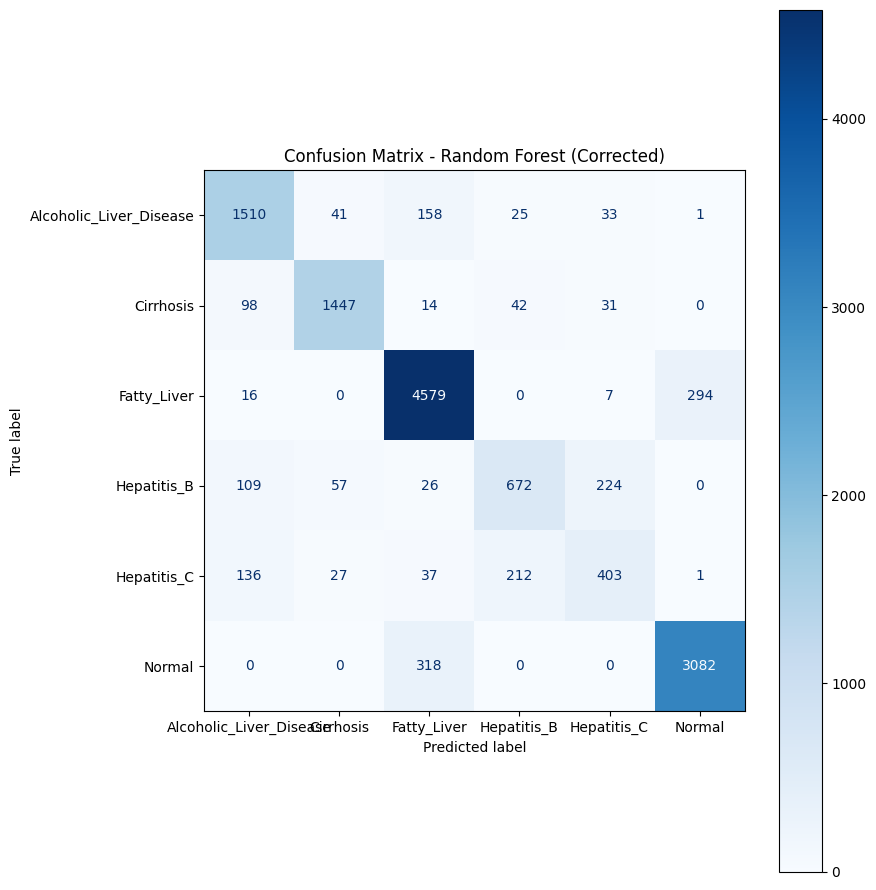

                   feature  importance
22               Bilirubin    0.216132
21                     AST    0.181191
20                     ALT    0.131706
23                 Albumin    0.087750
24               Platelets    0.054250
11            Sym_Jaundice    0.048853
15          Sym_Dark_Urine    0.048338
10             Sym_Fatigue    0.041588
17         Comorb_Diabetes    0.018162
14             Sym_Ascites    0.015059
12      Sym_Abdominal_Pain    0.011368
13             Sym_Itching    0.009221
16         Sym_Weight_Loss    0.002603
2               Occupation    0.001647
19  Comorb_Genetic_History    0.001485
25         Alk_Phosphatase    0.001353
8           Smoking_Status    0.001059
7              Sleep_Hours    0.000868
5             Diet_Quality    0.000853
6        Physical_Activity    0.000735


<Figure size 640x480 with 0 Axes>

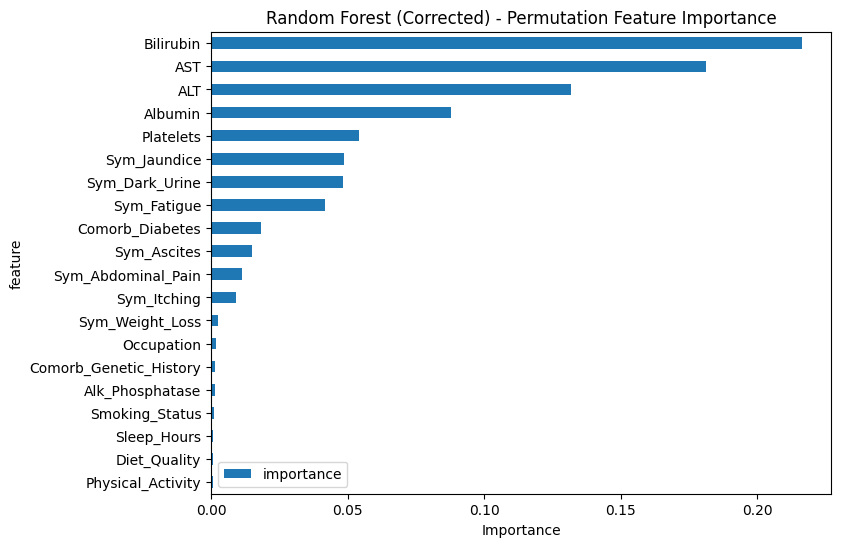

In [ ]:
# =============================================
# Random Forest with proper cv - Analysis
# =============================================

y_pred = best_model_rf_new.predict(X_test)
y_proba = best_model_rf_new.predict_proba(X_test)

accuracy_rf_new = accuracy_score(y_test, y_pred)
precision_rf_new = precision_score(y_test, y_pred, average='macro')
recall_rf_new = recall_score(y_test, y_pred, average='macro')
f1_rf_new = f1_score(y_test, y_pred, average='macro')
roc_auc_rf_new = roc_auc_score(y_test, y_proba, multi_class='ovr')

print("Best Train Score: ", grid_rf_new.score(X_train, y_train))
print("Best Test Score:  ", grid_rf_new.score(X_test, y_test))
print("Accuracy Score:   ", accuracy_rf_new)
print("Precision score:  ", precision_rf_new)
print("Recall score:     ", recall_rf_new)
print("F1 score:         ", f1_rf_new)
print("ROC-AUC:          ", roc_auc_rf_new)

# appending to the results array
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_rf_new,
    'Precision': precision_rf_new,
    'Recall': recall_rf_new,
    'F1 Score': f1_rf_new,
    'ROC-AUC': roc_auc_rf_new
})

perform_classification_analysis(y_test, y_pred, "Random Forest (Corrected)")

perform_confusionmatrix_analysis(y_test, y_pred, "Random Forest (Corrected)")

perform_feature_importance_analysis(best_model_rf_new, X_test, y_test, "Random Forest (Corrected)")

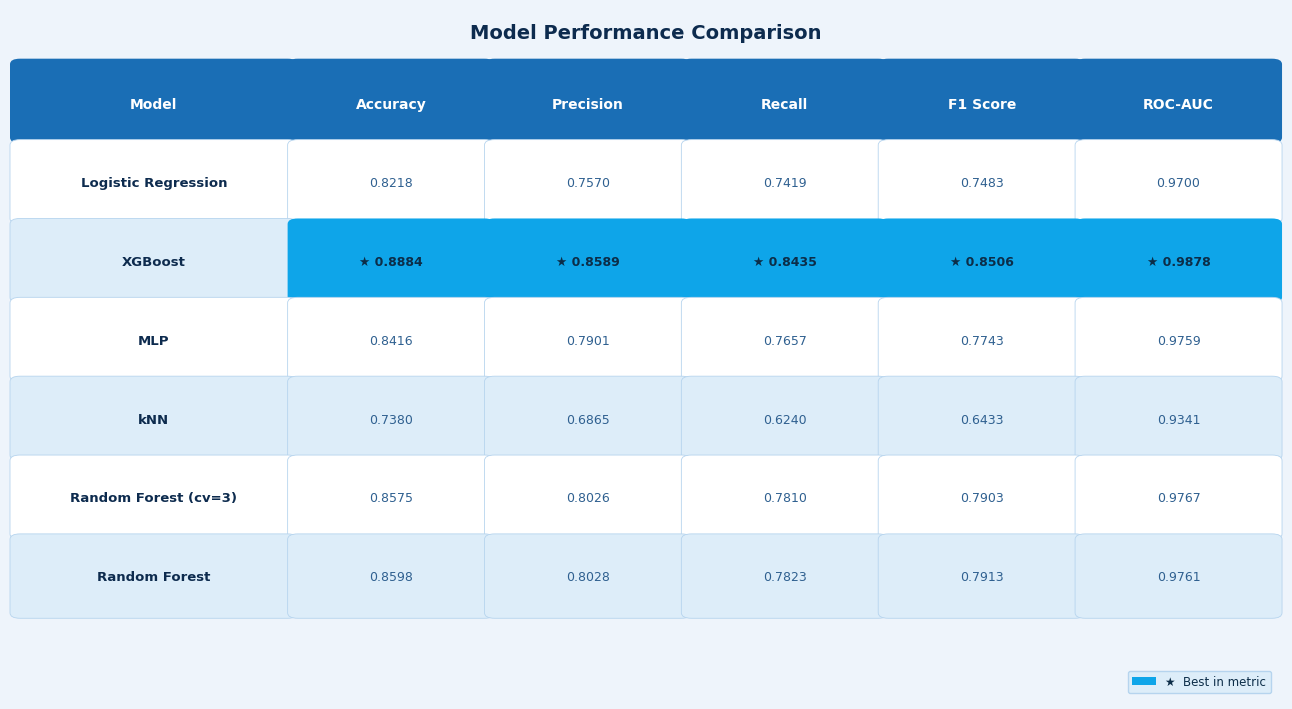

In [ ]:
plot_model_comparison(results)

External test set shape: (1500, 26)
Class distribution:
Liver_Disease_Type
2    540
5    375
0    195
1    180
3    120
4     90
Name: count, dtype: int64

Evaluating Logistic Regression...
  Accuracy : 0.8293
  Precision: 0.7636
  Recall   : 0.7574
  F1 Score : 0.7602
  ROC-AUC  : 0.9731

{'0': {'precision': 0.7783505154639175, 'recall': 0.7743589743589744, 'f1-score': 0.7763496143958869, 'support': 195.0}, '1': {'precision': 0.8666666666666667, 'recall': 0.8666666666666667, 'f1-score': 0.8666666666666667, 'support': 180.0}, '2': {'precision': 0.8859813084112149, 'recall': 0.8777777777777778, 'f1-score': 0.881860465116279, 'support': 540.0}, '3': {'precision': 0.6271186440677966, 'recall': 0.6166666666666667, 'f1-score': 0.6218487394957983, 'support': 120.0}, '4': {'precision': 0.5432098765432098, 'recall': 0.4888888888888889, 'f1-score': 0.5146198830409356, 'support': 90.0}, '5': {'precision': 0.8801020408163265, 'recall': 0.92, 'f1-score': 0.8996088657105606, 'support': 375.0}, 'acc

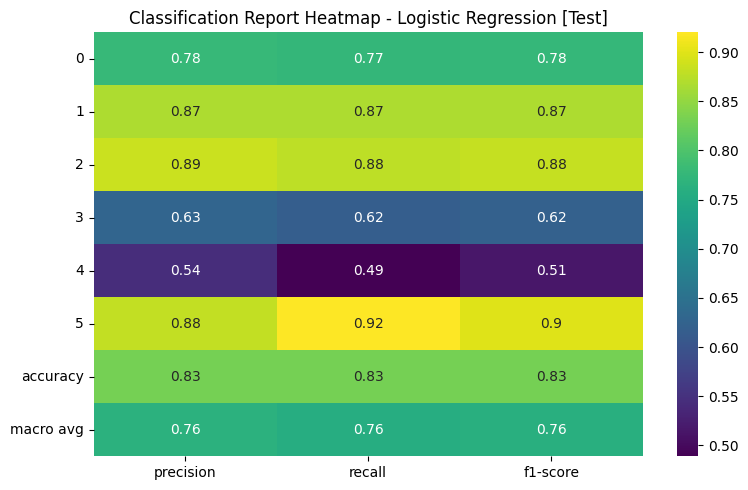

[[151  10  25   4   5   0]
 [ 13 156   1   7   3   0]
 [ 15   0 474   0   4  47]
 [  7  12   2  74  25   0]
 [  8   2   3  33  44   0]
 [  0   0  30   0   0 345]]


<Figure size 640x480 with 0 Axes>

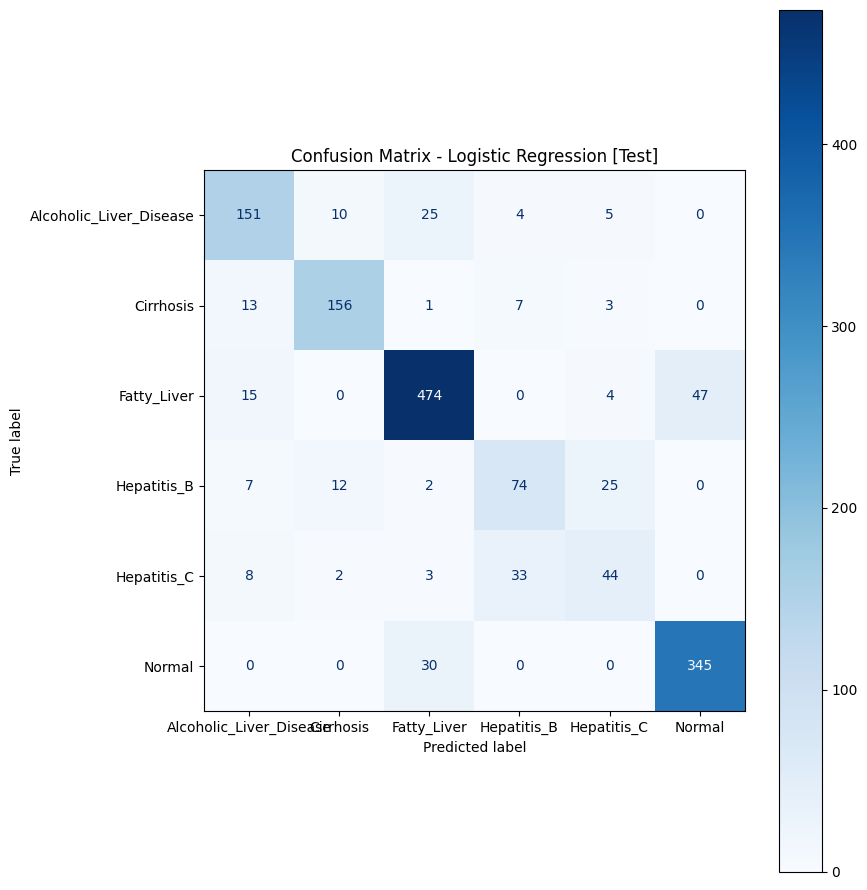

Evaluating XGBoost...
  Accuracy : 0.9127
  Precision: 0.8861
  Recall   : 0.8813
  F1 Score : 0.8833
  ROC-AUC  : 0.9917

{'0': {'precision': 0.893048128342246, 'recall': 0.8564102564102564, 'f1-score': 0.8743455497382199, 'support': 195.0}, '1': {'precision': 0.9428571428571428, 'recall': 0.9166666666666666, 'f1-score': 0.9295774647887324, 'support': 180.0}, '2': {'precision': 0.9312839059674503, 'recall': 0.9537037037037037, 'f1-score': 0.9423604757548033, 'support': 540.0}, '3': {'precision': 0.868421052631579, 'recall': 0.825, 'f1-score': 0.8461538461538461, 'support': 120.0}, '4': {'precision': 0.7422680412371134, 'recall': 0.8, 'f1-score': 0.7700534759358288, 'support': 90.0}, '5': {'precision': 0.9385026737967914, 'recall': 0.936, 'f1-score': 0.9372496662216289, 'support': 375.0}, 'accuracy': 0.9126666666666666, 'macro avg': {'precision': 0.8860634908053872, 'recall': 0.8812967711301044, 'f1-score': 0.8832900797655099, 'support': 1500.0}, 'weighted avg': {'precision': 0.9131367

<Figure size 640x480 with 0 Axes>

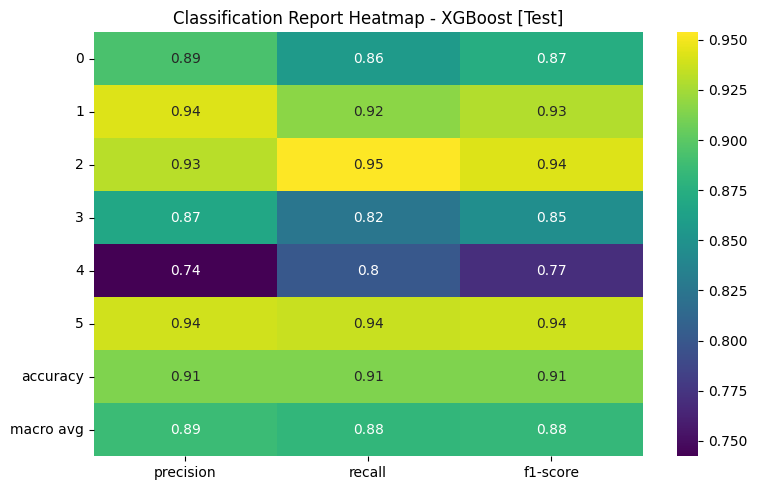

[[167   7  12   3   6   0]
 [  9 165   1   2   3   0]
 [  2   0 515   0   0  23]
 [  4   1   0  99  16   0]
 [  5   2   1  10  72   0]
 [  0   0  24   0   0 351]]


<Figure size 640x480 with 0 Axes>

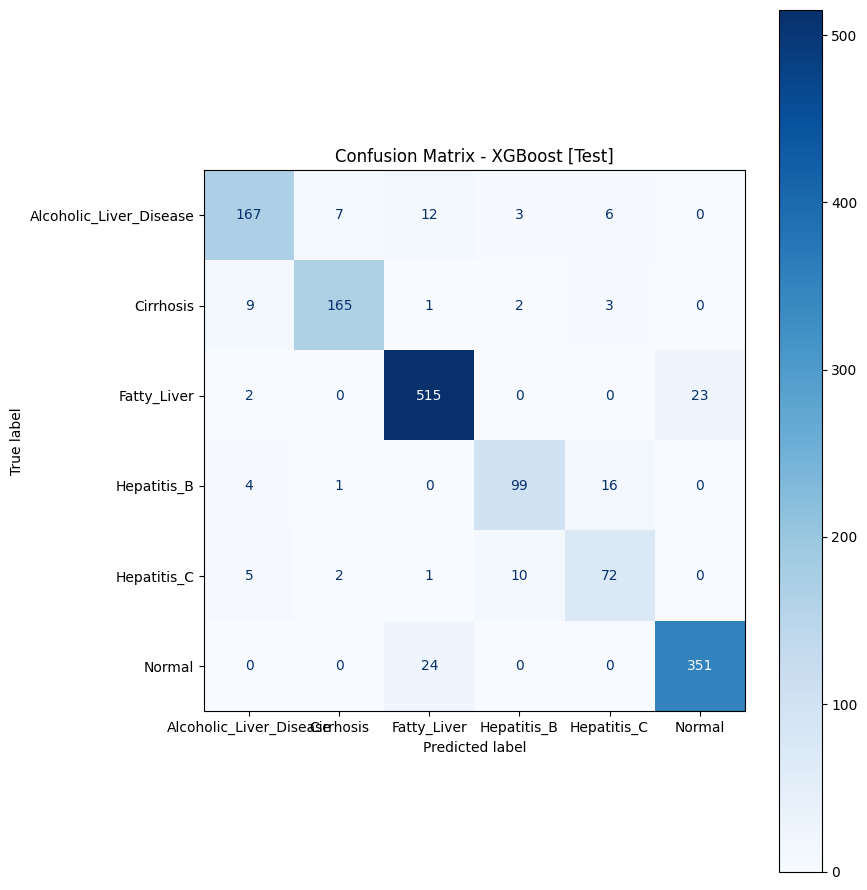

Evaluating MLP...
  Accuracy : 0.8627
  Precision: 0.8237
  Recall   : 0.8011
  F1 Score : 0.8042
  ROC-AUC  : 0.9806

{'0': {'precision': 0.8677248677248677, 'recall': 0.841025641025641, 'f1-score': 0.8541666666666666, 'support': 195.0}, '1': {'precision': 0.8994413407821229, 'recall': 0.8944444444444445, 'f1-score': 0.8969359331476323, 'support': 180.0}, '2': {'precision': 0.9012797074954296, 'recall': 0.912962962962963, 'f1-score': 0.9070837166513339, 'support': 540.0}, '3': {'precision': 0.821917808219178, 'recall': 0.5, 'f1-score': 0.6217616580310881, 'support': 120.0}, '4': {'precision': 0.5701754385964912, 'recall': 0.7222222222222222, 'f1-score': 0.6372549019607843, 'support': 90.0}, '5': {'precision': 0.8819095477386935, 'recall': 0.936, 'f1-score': 0.908150064683053, 'support': 375.0}, 'accuracy': 0.8626666666666667, 'macro avg': {'precision': 0.823741451759464, 'recall': 0.8011092117758785, 'f1-score': 0.804225490190093, 'support': 1500.0}, 'weighted avg': {'precision': 0.86

<Figure size 640x480 with 0 Axes>

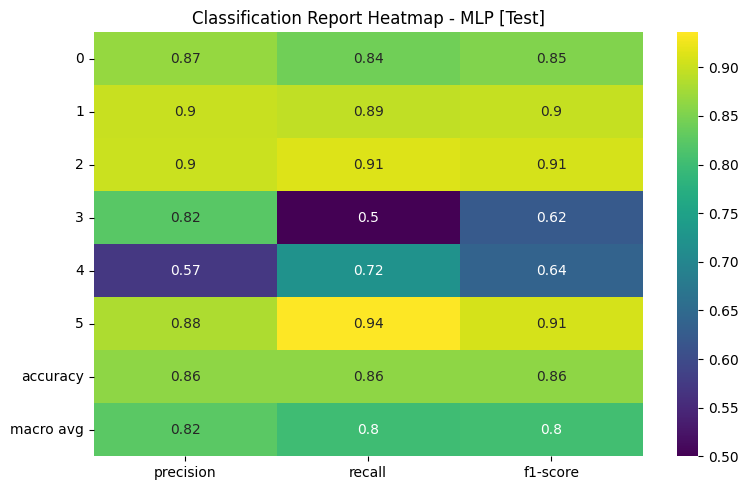

[[164   4  22   1   4   0]
 [ 11 161   1   1   6   0]
 [  0   0 493   0   0  47]
 [  6  13   2  60  39   0]
 [  8   1   5  11  65   0]
 [  0   0  24   0   0 351]]


<Figure size 640x480 with 0 Axes>

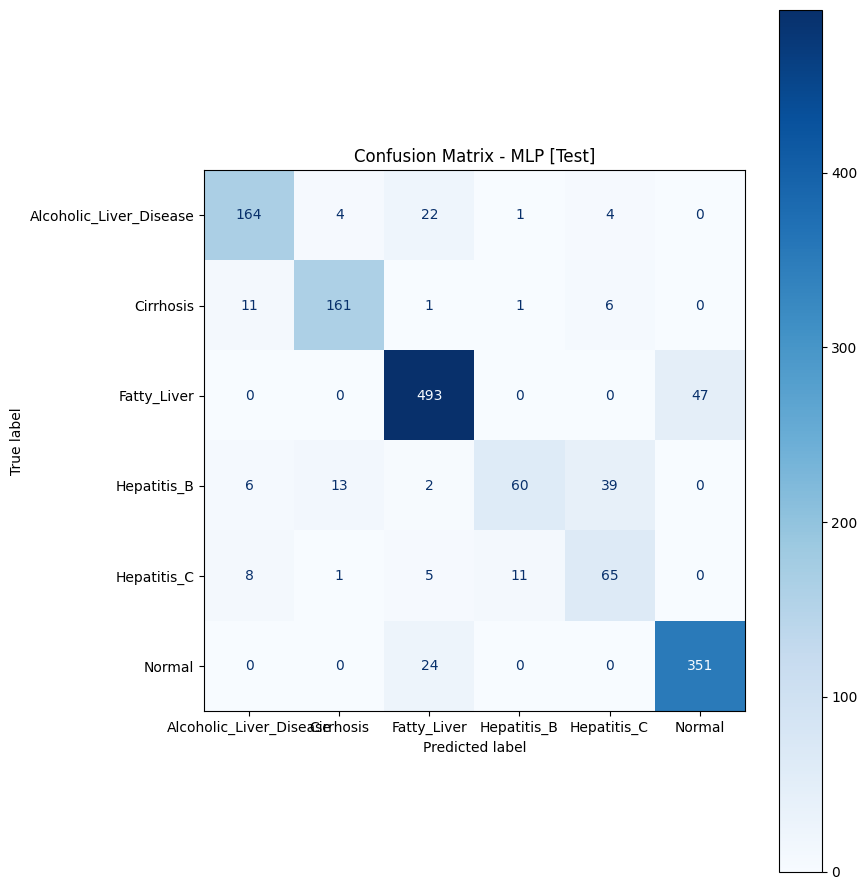

Evaluating kNN...
  Accuracy : 0.7907
  Precision: 0.7131
  Recall   : 0.6421
  F1 Score : 0.6639
  ROC-AUC  : 0.9496

{'0': {'precision': 0.5799086757990868, 'recall': 0.6512820512820513, 'f1-score': 0.6135265700483091, 'support': 195.0}, '1': {'precision': 0.8905109489051095, 'recall': 0.6777777777777778, 'f1-score': 0.7697160883280757, 'support': 180.0}, '2': {'precision': 0.802773497688752, 'recall': 0.9648148148148148, 'f1-score': 0.8763666947014298, 'support': 540.0}, '3': {'precision': 0.5625, 'recall': 0.375, 'f1-score': 0.45, 'support': 120.0}, '4': {'precision': 0.5, 'recall': 0.25555555555555554, 'f1-score': 0.3382352941176471, 'support': 90.0}, '5': {'precision': 0.943089430894309, 'recall': 0.928, 'f1-score': 0.9354838709677419, 'support': 375.0}, 'accuracy': 0.7906666666666666, 'macro avg': {'precision': 0.7131304255478762, 'recall': 0.6420716999050332, 'f1-score': 0.663888086360534, 'support': 1500.0}, 'weighted avg': {'precision': 0.7820202586140224, 'recall': 0.7906666

<Figure size 640x480 with 0 Axes>

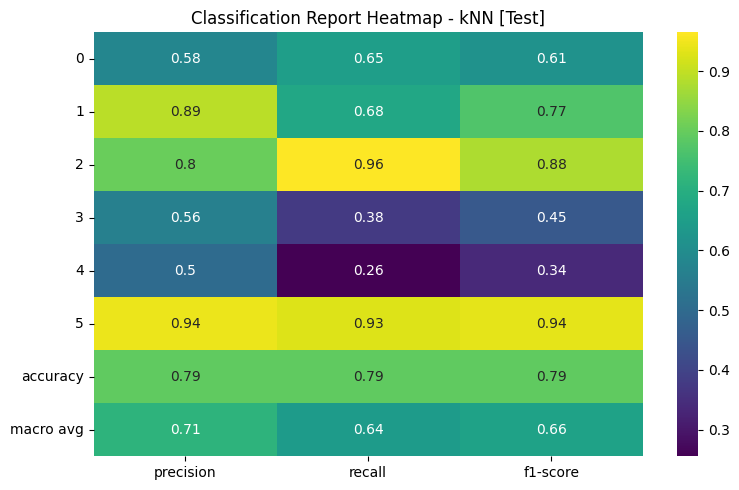

[[127   4  57   4   1   2]
 [ 40 122  16   2   0   0]
 [  0   0 521   0   0  19]
 [ 31  10  12  45  22   0]
 [ 21   1  16  29  23   0]
 [  0   0  27   0   0 348]]


<Figure size 640x480 with 0 Axes>

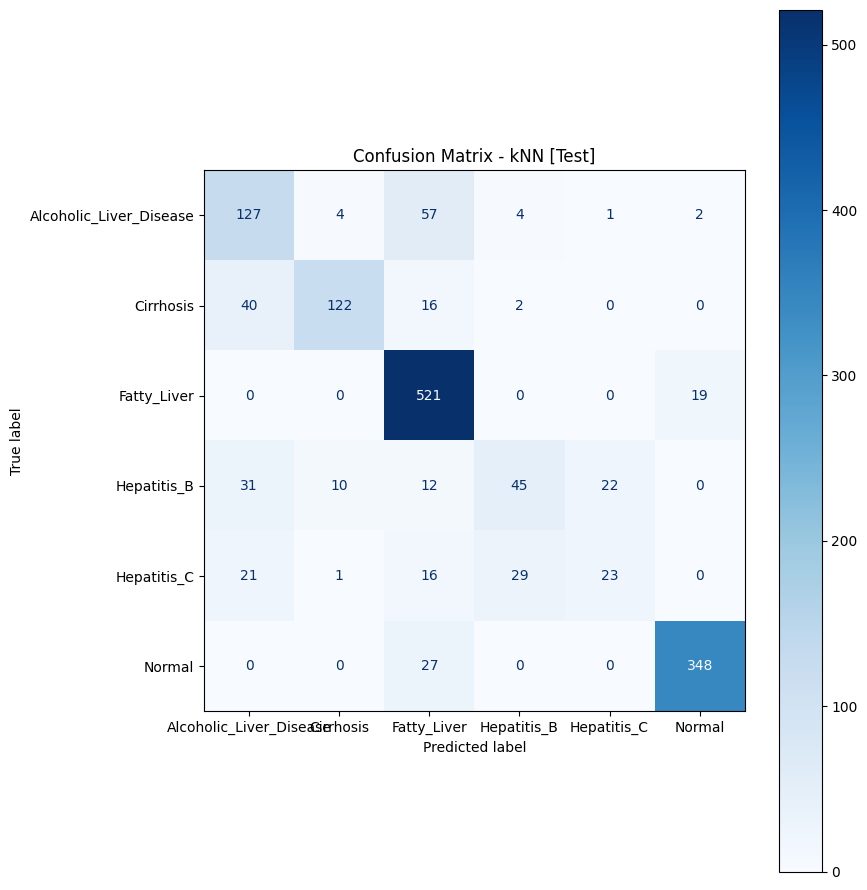

Evaluating Random Forest (cv=3)...
  Accuracy : 0.8847
  Precision: 0.8302
  Recall   : 0.8132
  F1 Score : 0.8209
  ROC-AUC  : 0.9834

{'0': {'precision': 0.8636363636363636, 'recall': 0.8769230769230769, 'f1-score': 0.8702290076335878, 'support': 195.0}, '1': {'precision': 0.9314285714285714, 'recall': 0.9055555555555556, 'f1-score': 0.9183098591549296, 'support': 180.0}, '2': {'precision': 0.9106830122591943, 'recall': 0.9629629629629629, 'f1-score': 0.9360936093609361, 'support': 540.0}, '3': {'precision': 0.7281553398058253, 'recall': 0.625, 'f1-score': 0.672645739910314, 'support': 120.0}, '4': {'precision': 0.6022727272727273, 'recall': 0.5888888888888889, 'f1-score': 0.5955056179775281, 'support': 90.0}, '5': {'precision': 0.9452054794520548, 'recall': 0.92, 'f1-score': 0.9324324324324325, 'support': 375.0}, 'accuracy': 0.8846666666666667, 'macro avg': {'precision': 0.8302302489757895, 'recall': 0.8132217473884141, 'f1-score': 0.8208693777449546, 'support': 1500.0}, 'weighted a

<Figure size 640x480 with 0 Axes>

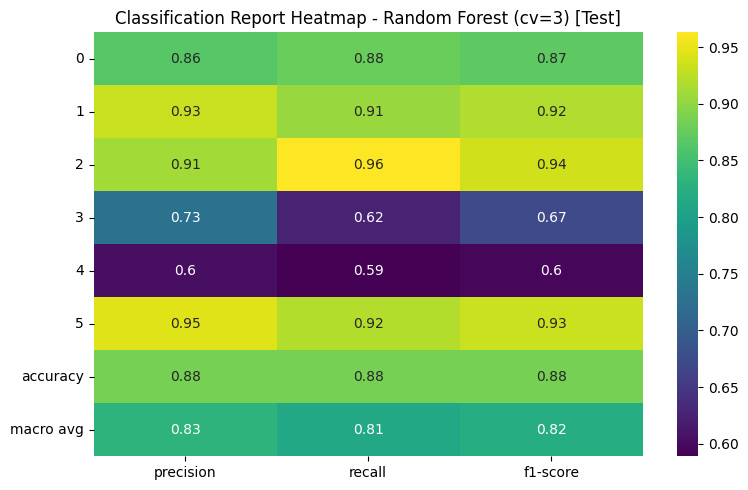

[[171   4  14   2   4   0]
 [ 10 163   2   2   3   0]
 [  0   0 520   0   0  20]
 [  7   7   3  75  28   0]
 [ 10   1   2  24  53   0]
 [  0   0  30   0   0 345]]


<Figure size 640x480 with 0 Axes>

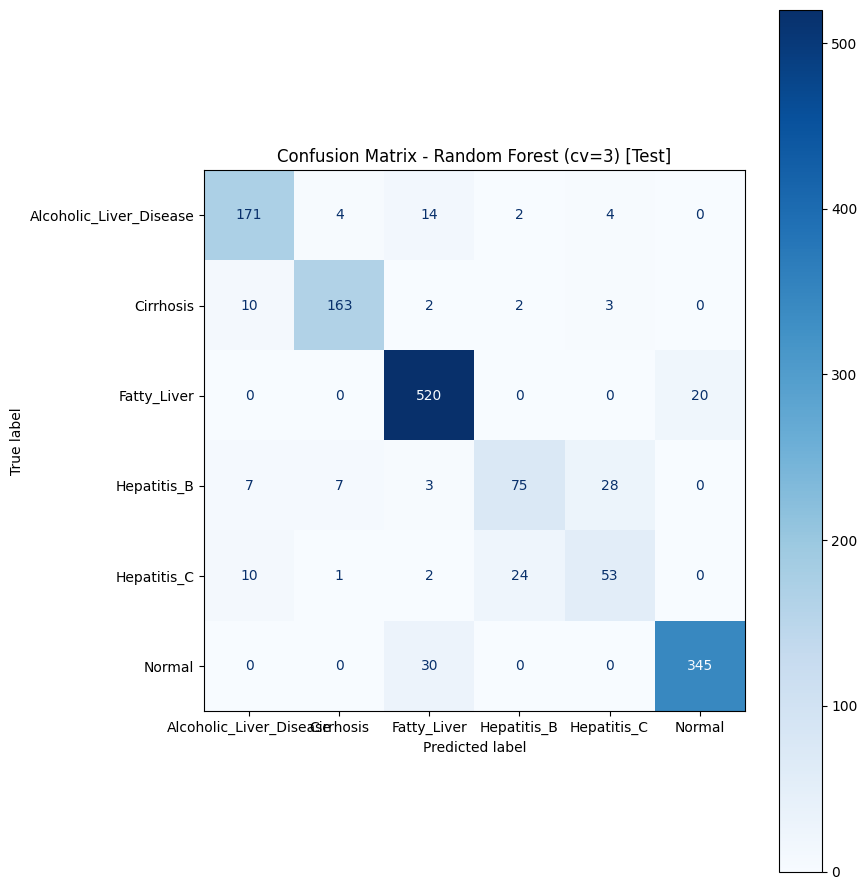

Evaluating Random Forest...
  Accuracy : 0.8980
  Precision: 0.8436
  Recall   : 0.8248
  F1 Score : 0.8330
  ROC-AUC  : 0.9841

{'0': {'precision': 0.8808290155440415, 'recall': 0.8717948717948718, 'f1-score': 0.8762886597938144, 'support': 195.0}, '1': {'precision': 0.9213483146067416, 'recall': 0.9111111111111111, 'f1-score': 0.9162011173184358, 'support': 180.0}, '2': {'precision': 0.9145299145299145, 'recall': 0.9907407407407407, 'f1-score': 0.9511111111111111, 'support': 540.0}, '3': {'precision': 0.7326732673267327, 'recall': 0.6166666666666667, 'f1-score': 0.669683257918552, 'support': 120.0}, '4': {'precision': 0.6263736263736264, 'recall': 0.6333333333333333, 'f1-score': 0.6298342541436464, 'support': 90.0}, '5': {'precision': 0.9857954545454546, 'recall': 0.9253333333333333, 'f1-score': 0.9546079779917469, 'support': 375.0}, 'accuracy': 0.898, 'macro avg': {'precision': 0.8435915988210851, 'recall': 0.8248300094966762, 'f1-score': 0.832954396379551, 'support': 1500.0}, 'weig

<Figure size 640x480 with 0 Axes>

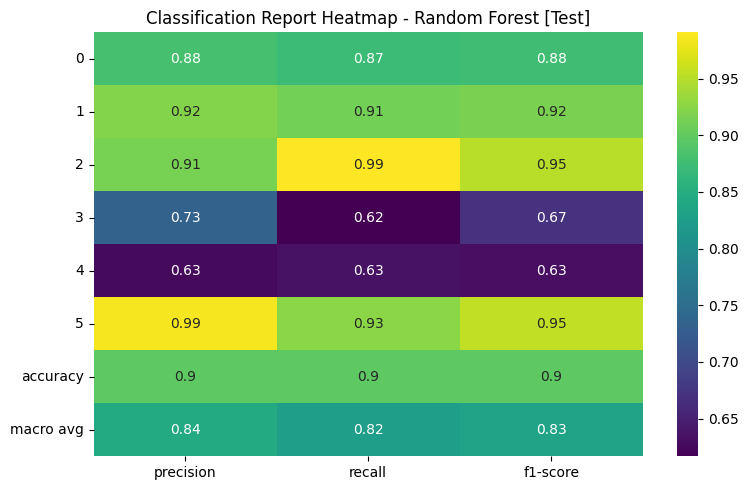

[[170   4  15   3   3   0]
 [ 10 164   2   2   2   0]
 [  0   0 535   0   0   5]
 [  5   9   3  74  29   0]
 [  8   1   2  22  57   0]
 [  0   0  28   0   0 347]]


<Figure size 640x480 with 0 Axes>

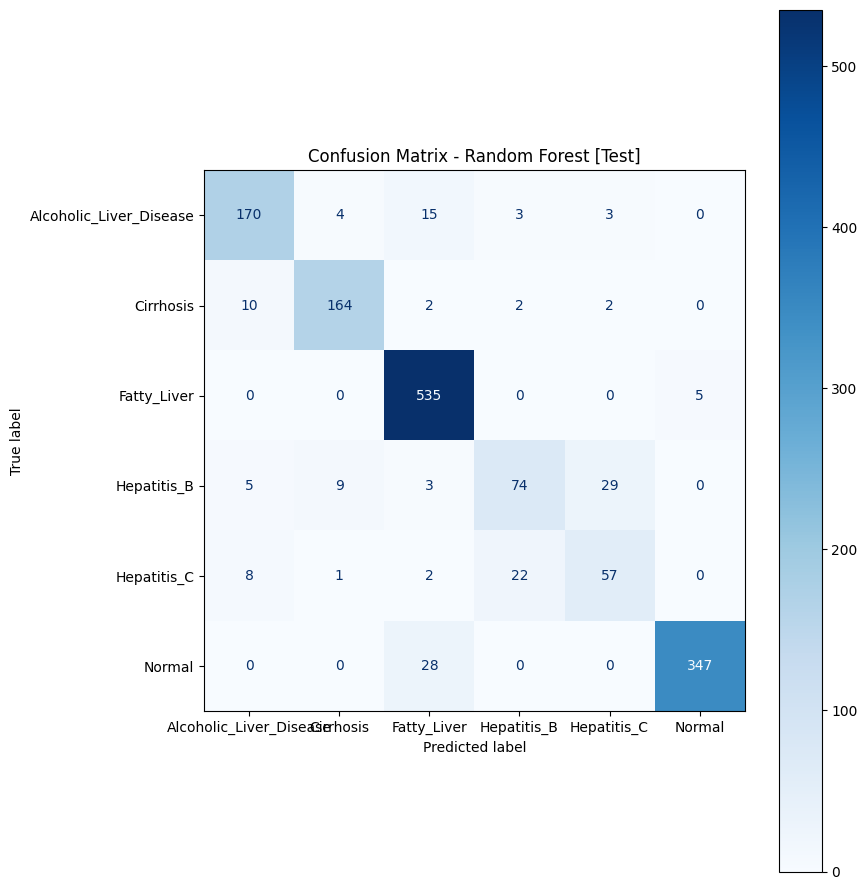


=== MODEL COMPARISON — EXTERNAL TEST SET ===


<Figure size 640x480 with 0 Axes>

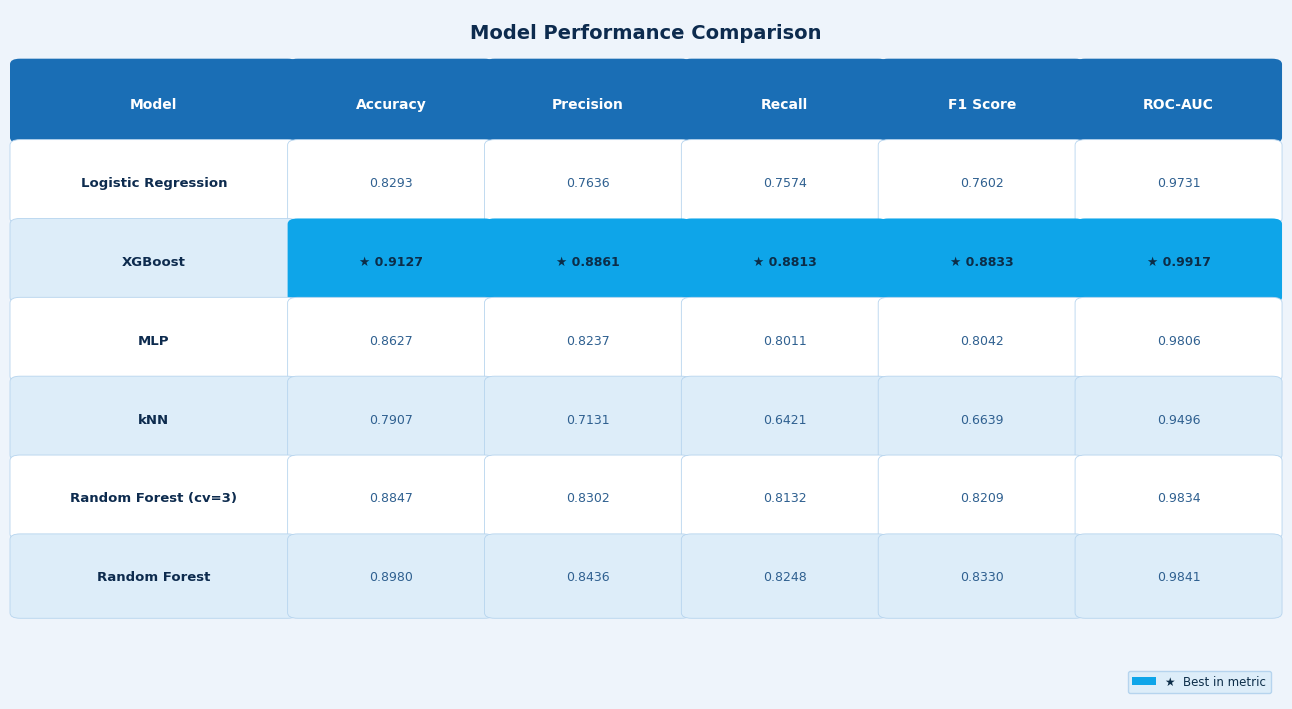

In [ ]:
# ============================================================
# FINAL EVALUATION ON EXTERNAL TEST SET
# ============================================================

test_url = 'https://raw.githubusercontent.com/saketh242/DS675-MiniProject-Saketh-Travis-Krishna/refs/heads/main/data/Testing_indian_liver_disease_dataset.csv'

# --- Load & prep external test data (mirror training preprocessing) ---
df_test = pd.read_csv(test_url, on_bad_lines='warn', keep_default_na=False)
df_test.drop(columns=['Patient_ID'], inplace=True, errors='ignore')
df_test['Liver_Disease_Type'] = le_target.transform(df_test['Liver_Disease_Type'])

X_ext = df_test.drop(columns=['Liver_Disease_Type'])
y_ext = df_test['Liver_Disease_Type']

print(f"External test set shape: {X_ext.shape}")
print(f"Class distribution:\n{y_ext.value_counts()}\n")

# --- Model registry ---
models = {
    'Logistic Regression':  best_model_lr,
    'XGBoost':              best_model_xgb,
    'MLP':                  best_model_mlp,
    'kNN':                  best_model,
    'Random Forest (cv=3)': best_model_rf,
    'Random Forest': best_model_rf_new
}

# --- Evaluate each model on external test set ---
test_results = []

for name, model in models.items():
    print(f"Evaluating {name}...")

    y_pred_ext  = model.predict(X_ext)
    y_proba_ext = model.predict_proba(X_ext)

    acc  = accuracy_score(y_ext, y_pred_ext)
    prec = precision_score(y_ext, y_pred_ext, average='macro', zero_division=0)
    rec  = recall_score(y_ext, y_pred_ext, average='macro', zero_division=0)
    f1   = f1_score(y_ext, y_pred_ext, average='macro', zero_division=0)
    auc  = roc_auc_score(y_ext, y_proba_ext, multi_class='ovr')

    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}\n")

    test_results.append({
        'Model':     name,
        'Accuracy':  acc,
        'Precision': prec,
        'Recall':    rec,
        'F1 Score':  f1,
        'ROC-AUC':   auc,
    })

    perform_classification_analysis(y_ext, y_pred_ext, f"{name} [Test]")
    perform_confusionmatrix_analysis(y_ext, y_pred_ext, f"{name} [Test]")

# --- Final comparison plot on external test set ---
print("\n=== MODEL COMPARISON — EXTERNAL TEST SET ===")
plot_model_comparison(test_results)